In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fftfreq
import ipywidgets as widgets
from IPython.display import display
import sys

import mlx.core as mx

sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm

print(f"MLX: {mx.__version__}, xsmurf: {xsm.__version__}")
# --- Shear-zone additions ---
try:
    from orix.quaternion import Orientation, Rotation
    from orix.quaternion.symmetry import D2, D3, C1
    _HAS_ORIX = True
    print(f'orix available for rotation + symmetry ops')
except ImportError:
    _HAS_ORIX = False
    print('orix not in this env — rotation + KAM fall back to pure-numpy path')

JOSEPHINE_ROTATION_XLSX = Path('EBSD/Josephine_Peridotite_Olivine/1365-3_RotationMetadata.xlsx')
EBSD_DIR = Path('/Users/amasaryk/projects/Creep/wavelet/EBSD')


MLX: 0.31.1, xsmurf: 0.1.0
orix available for rotation + symmetry ops


In [2]:
def compute_scales(n_oct, n_vox, a_min=1.863):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


def compute_scales_physical(n_oct, n_vox, target_min_um, px_um):
    """Compute scales so the smallest wavelet = target_min_um in physical units.
    Returns (scales_px, a_min_px) where scales are in pixels."""
    norm = 6.0 / 0.86
    a_min_px = target_min_um / (px_um * norm)
    scales = [a_min_px * (2.0 ** (o + v / n_vox)) * norm
              for o in range(n_oct) for v in range(n_vox)]
    return scales, a_min_px

# # Pixel-based version (kept for reference):
# def compute_scales(n_oct, n_vox, a_min=1):
#     norm = 6.0 / 0.86
#     return [a_min * (2.0 ** (o + v / n_vox)) * norm
#             for o in range(n_oct) for v in range(n_vox)]

print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')
print('compute_scales_physical: set minimum wavelet in um, not pixels')


CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined
compute_scales_physical: set minimum wavelet in um, not pixels


In [3]:
%matplotlib widget


In [4]:
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf (Channel Text File) EBSD dataset.
    
    Returns
    -------
    data : dict with 2D arrays for each field + metadata dict
    """
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()

    meta = {'filepath': str(filepath), 'name': filepath.stem}
    phases = {}
    header_line = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith('XCells'):
            meta['xcells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('YCells'):
            meta['ycells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('XStep'):
            meta['xstep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('YStep'):
            meta['ystep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('Phases'):
            n_phases = int(stripped.split('\t')[1])
            for j in range(1, n_phases + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = n_phases
        elif stripped.startswith('Phase\tX\tY'):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"Could not find data header in {filepath}")

    # Read tabular data
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, engine='python',
                     on_bad_lines='skip')
    
    nx, ny = meta['xcells'], meta['ycells']
    expected = nx * ny
    actual = len(df)
    if actual != expected:
        print(f"  Warning: expected {expected} rows ({nx}x{ny}), got {actual}")
        # Truncate or pad
        if actual > expected:
            df = df.iloc[:expected]
        else:
            nx_adj = actual // ny if ny > 0 else nx
            meta['xcells'] = nx_adj
            nx = nx_adj

    data = {'meta': meta}
    shape = (ny, nx)
    for col in df.columns:
        try:
            data[col] = df[col].values.reshape(shape)
        except ValueError:
            data[col] = df[col].values  # keep flat if reshape fails

    # Convenience aliases
    data['euler1'] = data.get('Euler1', None)
    data['euler2'] = data.get('Euler2', None)
    data['euler3'] = data.get('Euler3', None)
    data['bc'] = data.get('BC', None)
    data['bs'] = data.get('BS', None)
    data['mad'] = data.get('MAD', None)
    data['phase'] = data.get('Phase', None)

    print(f"  Loaded {filepath.name}: {nx} x {ny}, step={meta.get('xstep','?')} µm, "
          f"{meta.get('n_phases','?')} phases")
    return data
# --- Oxford Instruments Channel 5 .cpr/.crc binary reader ---
# Pure-numpy reader for .cpr (ASCII INI metadata) + .crc (binary data) pairs.
# Field code mapping taken from defdap.file_readers.OxfordBinaryLoader source.
# Unlike defdap's loader, this one does NOT construct a crystal Phase object
# so it works for any Laue group (including trigonal quartz, monoclinic
# feldspars, etc.) that the narrow defdap Phase class would reject.

import re as _re_cpr

_CPR_FIELD_LOOKUP = {
    3:  ('ph1',      'float32'),   # Euler1 phi1 (rad)
    4:  ('phi',      'float32'),   # Euler2 Phi  (rad)
    5:  ('ph2',      'float32'),   # Euler3 phi2 (rad)
    6:  ('MAD',      'float32'),   # mean angular deviation
    7:  ('BC',       'uint8'),     # band contrast
    8:  ('BS',       'uint8'),     # band slope
    10: ('numBands', 'uint8'),
    11: ('AFI',      'uint8'),
    12: ('IB6',      'float32'),
}


def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}
    current = None
    group_re = _re_cpr.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'):
            continue
        m = group_re.match(line)
        if m:
            current = m.group(1)
            groups.setdefault(current, {})
            continue
        if current is None:
            continue
        if '=' in line:
            k, v = line.split('=', 1)
            groups[current][k.strip()] = v.strip()
    return groups


def read_cpr(filepath):
    """Read an Oxford Instruments .cpr/.crc file pair.

    Returns the same dict shape as read_ctf():
        meta          dict with xcells, ycells, xstep, ystep, phases, n_phases, name
        euler1/2/3    (ny, nx) float32 arrays in DEGREES
        phase         (ny, nx) uint8 array
        bc, bs, mad   (ny, nx) arrays if present
        Plus any EDX windows as EDX_<element> keys.
    """
    filepath = Path(filepath)
    cpr_path = filepath.with_suffix('.cpr')
    crc_path = filepath.with_suffix('.crc')
    if not cpr_path.exists():
        raise FileNotFoundError(f"CPR header not found: {cpr_path}")
    if not crc_path.exists():
        raise FileNotFoundError(f"CRC binary not found: {crc_path}")

    groups = _parse_cpr_ini(cpr_path)

    # Grid & step
    job = groups.get('Job', {})
    nx = int(job['xCells'])
    ny = int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))

    # Phases: assemble ctf-like metadata so downstream cells keep working
    pg = groups.get('Phases', {})
    n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = groups.get(f'Phase{i}', {})
        lattice = '{};{};{}'.format(pi.get('a', '?'), pi.get('b', '?'), pi.get('c', '?'))
        angles = '{};{};{}'.format(pi.get('alpha', '?'), pi.get('beta', '?'), pi.get('gamma', '?'))
        phases[i] = [lattice, angles,
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]

    # EDX window names (field codes 100+i)
    edx_names = {}
    edx_group = groups.get('EDX Windows', {})
    if edx_group:
        n_edx = int(edx_group.get('Count', 0))
        for i in range(1, n_edx + 1):
            key = edx_group.get(f'Window{i}', f'edx{i}')
            edx_names[100 + i] = key

    # Build the binary record dtype from the [Fields] section
    fg = groups.get('Fields', {})
    n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]   # phase is always first, uint8
    unknown = 0
    for i in range(1, n_fields + 1):
        code = int(fg[f'Field{i}'])
        if code in _CPR_FIELD_LOOKUP:
            dtype_items.append(_CPR_FIELD_LOOKUP[code])
        elif code in edx_names:
            dtype_items.append((f'EDX_{edx_names[code]}', 'float32'))
        else:
            unknown += 1
            dtype_items.append((f'unknown_{unknown}_code{code}', 'float32'))
            print(f'  warning: unknown CPR field code {code}, guessing float32')
    record_dtype = np.dtype(dtype_items)

    # Load binary
    raw = np.fromfile(str(crc_path), dtype=record_dtype, count=nx * ny)
    if raw.size != nx * ny:
        raw = raw[:nx * ny]
        print(f'  warning: CRC short read ({raw.size} records)')

    shape = (ny, nx)
    data = {'meta': {
        'filepath': str(filepath),
        'name': filepath.stem,
        'xcells': nx, 'ycells': ny,
        'xstep': xstep, 'ystep': ystep,
        'phases': phases, 'n_phases': n_phases,
        'format': 'cpr',
    }}

    data['phase'] = raw['phase'].reshape(shape)

    # CPR stores Euler in radians; convert to degrees to match ctf convention
    for raw_key, deg_key in [('ph1', 'euler1'), ('phi', 'euler2'), ('ph2', 'euler3')]:
        if raw_key in raw.dtype.names:
            data[deg_key] = np.rad2deg(raw[raw_key].reshape(shape)).astype(np.float32)

    if 'MAD' in raw.dtype.names: data['mad'] = raw['MAD'].reshape(shape)
    if 'BC'  in raw.dtype.names: data['bc']  = raw['BC'].reshape(shape)
    if 'BS'  in raw.dtype.names: data['bs']  = raw['BS'].reshape(shape)
    if 'numBands' in raw.dtype.names: data['bands'] = raw['numBands'].reshape(shape)
    for name in raw.dtype.names:
        if name.startswith('EDX_'):
            data[name] = raw[name].reshape(shape)

    print(f'  CPR: {nx}x{ny} @ {xstep} um, {n_phases} phases, {len(dtype_items)} fields')
    return data


def read_ebsd(filepath):
    """Dispatch to the right EBSD reader based on file extension."""
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    if ext == '.ctf':
        return read_ctf(filepath)
    elif ext in ('.cpr', '.crc'):
        return read_cpr(filepath)
    else:
        raise ValueError(f"Unsupported EBSD extension: {ext} (expected .ctf or .cpr/.crc)")


In [5]:
# ===== Load pressure shadow + ultramylonite — ALL phases =====

EBSD_DIR = Path('/Users/amasaryk/projects/Creep/wavelet/EBSD')
KUCKAUS_DIR = EBSD_DIR / 'Kuckaus_Namibia_Feldspar_Mylonite'

# Only these two samples
TARGET_FILES = ['Porphyroclast_pressure_shadow .cpr', 'Ultramylonite .cpr']
sample_files = [KUCKAUS_DIR / f for f in TARGET_FILES if (KUCKAUS_DIR / f).exists()]
print(f'Loading {len(sample_files)} samples:')
for p in sample_files:
    print(f'  {p.name}')

samples = {}
for p in sample_files:
    name = p.stem.strip()
    ebsd = read_ebsd(p)
    samples[name] = ebsd

# List ALL phases in each sample
for name, ebsd in samples.items():
    phases = ebsd['meta'].get('phases', {})
    total = (ebsd['phase'] > 0).sum()
    print(f'\n{name}: {total} indexed pixels')
    for pid, info in phases.items():
        pname = info[2] if len(info) > 2 else f'phase_{pid}'
        n_px = (ebsd['phase'] == int(pid)).sum()
        laue = info[3] if len(info) > 3 else '?'
        print(f'  Phase {pid}: {pname} (Laue={laue}) — {n_px} px ({100*n_px/max(total,1):.1f}%)')


Loading 2 samples:
  Porphyroclast_pressure_shadow .cpr
  Ultramylonite .cpr
  CPR: 750x751 @ 0.8 um, 5 phases, 20 fields
  CPR: 700x701 @ 0.2 um, 5 phases, 20 fields

Porphyroclast_pressure_shadow: 277781 indexed pixels
  Phase 1: Quartz-new (Laue=7) — 29580 px (10.6%)
  Phase 2: Orthoclase (Laue=2) — 157525 px (56.7%)
  Phase 3: Anorthite (Laue=1) — 83781 px (30.2%)
  Phase 4: Biotite (Laue=2) — 1664 px (0.6%)
  Phase 5: Muscovite (Laue=2) — 5231 px (1.9%)

Ultramylonite: 349980 indexed pixels
  Phase 1: Quartz-new (Laue=7) — 114753 px (32.8%)
  Phase 2: Orthoclase (Laue=2) — 149598 px (42.7%)
  Phase 3: Anorthite (Laue=1) — 76232 px (21.8%)
  Phase 4: Biotite (Laue=2) — 4365 px (1.2%)
  Phase 5: Muscovite (Laue=2) — 5032 px (1.4%)


In [6]:
# ===== Crop if needed (optional) =====
# Skip this cell if no cropping needed — samples are used as-is.

crop_widgets = {}
crop_figs = {}

# Only offer crops for samples that might be merged images
# For now, use the samples directly
print('No crops applied — using full images.')
print(f'{len(samples)} samples ready.')
for name, ebsd in samples.items():
    ny, nx = ebsd['phase'].shape
    print(f'  {name}: {nx}x{ny}')


No crops applied — using full images.
2 samples ready.
  Porphyroclast_pressure_shadow: 750x751
  Ultramylonite: 700x701


In [7]:
# ===== (Skip: no crops to apply) =====
# samples dict is already populated from cell 4.
print(f'{len(samples)} samples ready for per-phase analysis.')


2 samples ready for per-phase analysis.


Porphyroclast_pressure_shadow: KAM for Quartz-new (29580 px, Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]])...


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_2840/1889172638.py:44: RuntimeWarning: invalid value encountered in divide
  kam = np.where(count > 0, kam / count, 0)


Porphyroclast_pressure_shadow: KAM for Orthoclase (157525 px, Symmetry (2,) 2
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]])...
Porphyroclast_pressure_shadow: KAM for Anorthite (83781 px, Symmetry (1,) 1
[[1. 0. 0. 0.]])...
Porphyroclast_pressure_shadow: KAM for Biotite (1664 px, Symmetry (2,) 2
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]])...
Porphyroclast_pressure_shadow: KAM for Muscovite (5231 px, Symmetry (2,) 2
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]])...
  Porphyroclast_pressure_shadow: 5 phases, 277781 total px
Ultramylonite: KAM for Quartz-new (114753 px, Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]])...
Ultramylonite: KAM for Orthoclase (149598 px, Symmetry (2,) 2
[[1. 0. 0.

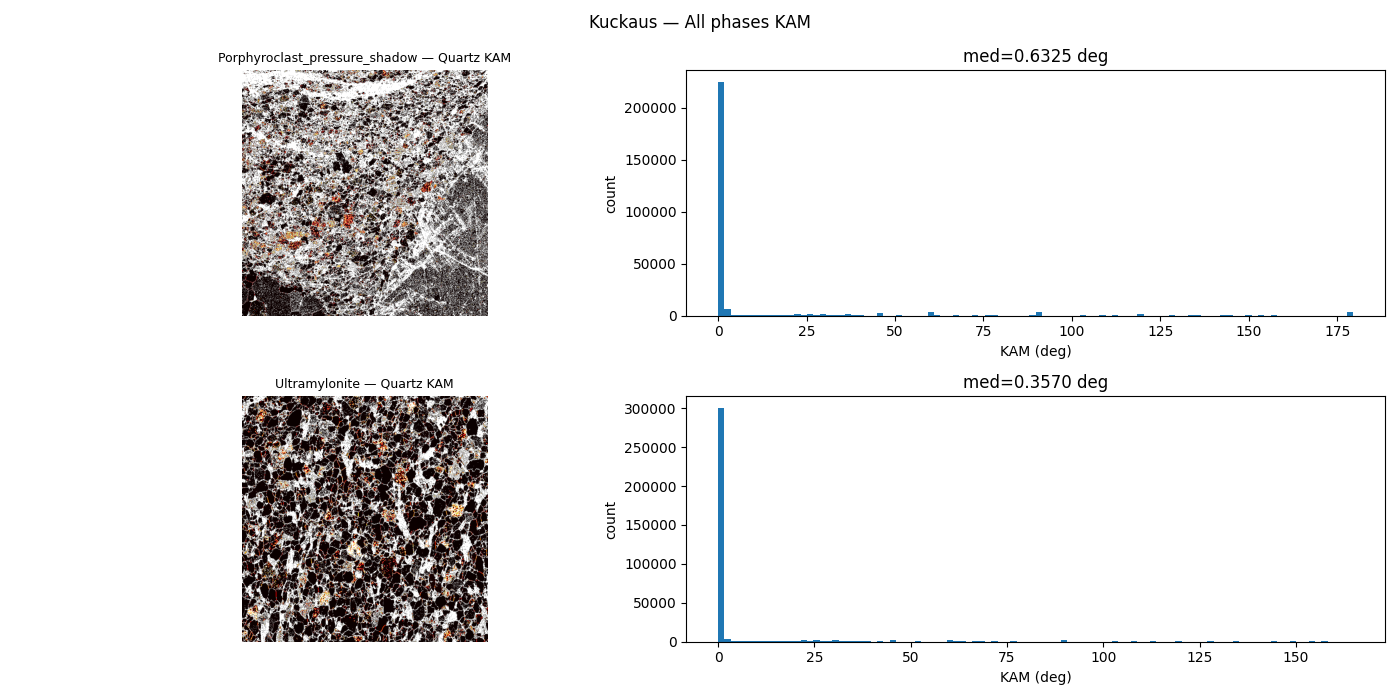

In [8]:
# ===== KAM per phase, ALL phases =====

from orix.quaternion import Orientation
from orix.quaternion.symmetry import C1, C2, D2, D3, D6, C4, Oh

LAUE_TO_ORIX = {
    '1': C1, '2': C2, '3': D2, '6': D3, '7': D6, '9': Oh, '11': C1,
}
KAM_KERNEL = 1

def get_phase_symmetry(ebsd_data, phase_id=1):
    phases = ebsd_data['meta'].get('phases', {})
    if phase_id in phases:
        info = phases[phase_id]
        laue_str = str(info[3]).strip() if len(info) > 3 else '?'
        sym = LAUE_TO_ORIX.get(laue_str, None)
        return sym if sym is not None else C1
    return C1

def compute_kam_orix(e1, e2, e3, symmetry, mask=None, kernel=1, degrees=True):
    ny, nx = e1.shape
    euler_rad = np.deg2rad(np.stack([e1, e2, e3], axis=-1)).astype(np.float64)
    ori = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=symmetry)
    ori = ori.reshape(ny, nx)
    kam = np.zeros((ny, nx), dtype=np.float64)
    count = np.zeros((ny, nx), dtype=np.float64)
    if mask is None: mask = np.ones((ny, nx), dtype=bool)
    offsets = [(dy, dx) for dy in range(-kernel, kernel+1) for dx in range(-kernel, kernel+1)
               if not (dy == 0 and dx == 0) and ((dy, dx) > (0, 0) or (dy == 0 and dx > 0))]
    for dy, dx in offsets:
        sy1 = slice(max(-dy, 0), ny - max(dy, 0))
        sy2 = slice(max(dy, 0), ny - max(-dy, 0))
        sx1 = slice(max(-dx, 0), nx - max(dx, 0))
        sx2 = slice(max(dx, 0), nx - max(-dx, 0))
        m = mask[sy1, sx1] & mask[sy2, sx2]
        if not m.any(): continue
        angles = np.full(m.shape, np.nan)
        angles[m] = ori[sy1, sx1][m].angle_with(ori[sy2, sx2][m])
        v = np.isfinite(angles)
        kam[sy1, sx1] += np.where(v, angles, 0)
        kam[sy2, sx2] += np.where(v, angles, 0)
        count[sy1, sx1] += v
        count[sy2, sx2] += v
    kam = np.where(count > 0, kam / count, 0)
    kam[~mask] = np.nan
    if degrees: kam = np.rad2deg(kam)
    return kam

# Compute KAM for ALL phases in each sample
sample_kam = {}
for name, ebsd in samples.items():
    phases = ebsd['meta'].get('phases', {})
    all_indexed = ebsd['phase'] > 0
    # Compute KAM using per-pixel symmetry (all phases together)
    # For multi-phase, compute per-phase then merge
    kam_full = np.full(ebsd['euler1'].shape, np.nan, dtype=np.float64)
    phase_info = {}
    for pid_str, info in phases.items():
        pid = int(pid_str)
        pname = info[2] if len(info) > 2 else f'phase_{pid}'
        mask_p = (ebsd['phase'] == pid)
        if mask_p.sum() < 10: continue
        sym = get_phase_symmetry(ebsd, pid)
        print(f'{name}: KAM for {pname} ({mask_p.sum()} px, {sym})...')
        kam_p = compute_kam_orix(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                                  symmetry=sym, mask=mask_p, kernel=KAM_KERNEL)
        kam_full[mask_p] = kam_p[mask_p]
        phase_info[pid] = {'name': pname, 'sym': sym, 'mask': mask_p, 'n_px': int(mask_p.sum())}
    sample_kam[name] = {'kam': kam_full, 'mask': all_indexed, 'phase_info': phase_info}
    print(f'  {name}: {len(phase_info)} phases, {all_indexed.sum()} total px')

# Plot
n_samples = len(sample_kam)
if n_samples == 0: print('No samples!'); n_samples = 1
fig, axes = plt.subplots(n_samples, 2, figsize=(14, 3.5 * n_samples), squeeze=False)
for row, (name, sk) in enumerate(sample_kam.items()):
    ax = axes[row, 0]
    ax.imshow(sk['kam'], cmap='hot', vmin=0, vmax=np.nanpercentile(sk['kam'], 95), aspect='equal')
    ax.set_title(f'{name} — Quartz KAM', fontsize=9); ax.axis('off')
    ax = axes[row, 1]
    vals = sk['kam'][np.isfinite(sk['kam'])]
    ax.hist(vals, bins=100, range=(0, np.nanpercentile(vals, 99)))
    ax.set(xlabel='KAM (deg)', ylabel='count', title=f'med={np.median(vals):.4f} deg')
plt.suptitle('Kuckaus — All phases KAM', fontsize=12)
plt.tight_layout()
plt.show()



In [ ]:
# ===== Log-orientation per phase, ALL phases =====

def _quat_mul(a, b):
    aw, ax, ay, az = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bw, bx, by, bz = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([aw*bw-ax*bx-ay*by-az*bz, aw*bx+ax*bw+ay*bz-az*by,
                     aw*by-ax*bz+ay*bw+az*bx, aw*bz+ax*by-ay*bx+az*bw], axis=-1)

def _quat_conj(q):
    return np.stack([q[..., 0], -q[..., 1], -q[..., 2], -q[..., 3]], axis=-1)

def compute_log_orientation(e1, e2, e3, mask, symmetry):
    ny, nx = e1.shape
    euler_rad = np.deg2rad(np.stack([e1[mask], e2[mask], e3[mask]], axis=1).astype(np.float64))
    ori = Orientation.from_euler(euler_rad, symmetry=symmetry)
    q_all = ori.data.copy()
    q_all *= np.where(q_all[:, 0:1] >= 0, 1.0, -1.0)
    n_pix = q_all.shape[0]
    T = (q_all.T @ q_all) / n_pix
    _, eigvecs = np.linalg.eigh(T)
    q_ref = eigvecs[:, -1]
    if q_ref[0] < 0: q_ref = -q_ref
    sym_q = symmetry.data
    for _ in range(5):
        q_sym = _quat_mul(q_all[:, None, :], sym_q[None, :, :])
        rel = _quat_mul(_quat_conj(q_ref)[None, None, :], q_sym)
        rel *= np.where(rel[..., 0:1] >= 0, 1.0, -1.0)
        best = np.argmax(rel[..., 0], axis=1)
        q_aligned = q_sym[np.arange(n_pix), best]
        q_aligned *= np.where(q_aligned[:, 0:1] >= 0, 1.0, -1.0)
        T = (q_aligned.T @ q_aligned) / n_pix
        _, eigvecs = np.linalg.eigh(T)
        q_new = eigvecs[:, -1]
        if q_new[0] < 0: q_new = -q_new
        if abs(float(q_ref @ q_new)) > 0.9999: break
        q_ref = q_new
    rel_best = _quat_mul(_quat_conj(q_ref)[None, :], q_aligned)
    rel_best *= np.where(rel_best[:, 0:1] >= 0, 1.0, -1.0)
    w = np.clip(rel_best[:, 0], -1.0, 1.0)
    theta = 2.0 * np.arccos(w)
    sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
    small = sin_half < 1e-8
    safe = np.where(small, 1.0, sin_half)
    axis = rel_best[:, 1:4] / safe[:, None]
    axis[small] = 0.0
    omega = theta[:, None] * axis
    omega[small] = 2.0 * rel_best[small, 1:4]
    log_field = np.zeros((ny, nx, 3), dtype=np.float32)
    yy, xx = np.where(mask)
    log_field[yy, xx, :] = omega.astype(np.float32)
    return log_field, q_ref

sample_log = {}
for name, ebsd in samples.items():
    ny, nx = ebsd['euler1'].shape
    phases = ebsd['meta'].get('phases', {})
    all_indexed = ebsd['phase'] > 0
    # Combined log-orientation: compute per phase, merge into one (ny, nx, 3) field
    lf_combined = np.zeros((ny, nx, 3), dtype=np.float32)
    phase_log_info = {}
    for pid_str, info in phases.items():
        pid = int(pid_str)
        pname = info[2] if len(info) > 2 else f'phase_{pid}'
        mask_p = (ebsd['phase'] == pid)
        if mask_p.sum() < 10: continue
        sym = get_phase_symmetry(ebsd, pid)
        print(f'{name}: log-orientation for {pname} ({mask_p.sum()} px)...')
        lf_p, q_ref_p = compute_log_orientation(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'], mask_p, sym)
        lf_combined[mask_p] = lf_p[mask_p]
        theta_p = np.sqrt(np.sum(lf_p[mask_p]**2, axis=-1))
        print(f'  theta med={np.rad2deg(np.median(theta_p)):.2f} p99={np.rad2deg(np.percentile(theta_p, 99)):.2f} deg')
        phase_log_info[pid] = {'q_ref': q_ref_p, 'name': pname, 'sym': sym}
    sample_log[name] = {'log_field': lf_combined, 'mask': all_indexed, 'phase_info': phase_log_info}

print('Done.')



In [77]:
# ===== Tensor SVD WTMM — all phases, multiple field sources =====

from xsmurf_wrapper.anchor_chain import chain_and_extract

# ---------- PARAMETERS ----------
FIELD_SOURCE = 'kam'  # 'log_orientation', 'nye', 'kam'
KAM_CLIP_DEG = 5.0               # clip KAM at this threshold when used as WTMM input (None = no clip)
WAVELET = 'mexican'
CHAIN_METHOD = 'greedy'
N_OCT = 3
N_VOX = 20
A_MIN = 1.863              # pixel-based minimum scale parameter
TARGET_MIN_UM = None       # set to a float (e.g. 10.0) to use physical units instead
PAD = 32
BORDER_PCT = 1.5
THRESH = 1e-1
SIMILITUDE = 0.8
DIST_FRAC = 0.2
FRACINT_ALPHA = 0.2
# ---------------------------------

if TARGET_MIN_UM is not None:
    print(f'Scale mode: physical, target minimum wavelet = {TARGET_MIN_UM} um')
else:
    print(f'Scale mode: pixel, A_MIN = {A_MIN}')

def fractional_integrate_2d(image, alpha, pad=None):
    """Fractional integration via FFT with mirror padding to suppress edge artifacts.
    f_hat(k) = f_hat(k) * |k|^{-alpha}.  pad = number of pixels (default: 25% of image size)."""
    if alpha == 0: return image
    ny, nx = image.shape
    if pad is None:
        pad = max(nx, ny) // 4
    # Mirror-pad to reduce edge discontinuities before FFT
    padded = np.pad(image.astype(np.float64), pad, mode='reflect')
    ny_p, nx_p = padded.shape
    kx, ky = np.fft.fftfreq(nx_p), np.fft.fftfreq(ny_p)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2; K2[0, 0] = 1.0
    filt = K2 ** (-alpha / 2.0); filt[0, 0] = 0.0
    result = np.real(np.fft.ifft2(np.fft.fft2(padded) * filt))
    return result[pad:pad+ny, pad:pad+nx].astype(np.float32)

# Nye tensor computation (inline, for 'nye' field source)
def _compute_nye_inline(ebsd_data, mask, phase_info):
    from orix.quaternion import Orientation
    from orix.quaternion.symmetry import C1
    e1=ebsd_data['euler1'].astype(np.float64); e2=ebsd_data['euler2'].astype(np.float64)
    e3=ebsd_data['euler3'].astype(np.float64)
    xstep=float(ebsd_data['meta'].get('xstep',1.0)); ystep=float(ebsd_data['meta'].get('ystep',xstep))
    ny,nx=e1.shape
    euler_rad=np.deg2rad(np.stack([e1,e2,e3],axis=-1))
    ori=Orientation.from_euler(euler_rad.reshape(-1,3),symmetry=C1)
    qf=ori.data.reshape(ny,nx,4).astype(np.float64)
    nye=np.zeros((ny,nx,2,3),dtype=np.float32)
    # Per-phase pairwise Nye
    for pid, pi in phase_info.items():
        mask_p = (ebsd_data['phase'] == pid)
        if mask_p.sum() < 10: continue
        sym_q = pi['sym'].data
        for di,(dy,dx,step) in enumerate([(0,1,xstep),(1,0,ystep)]):
            ya=slice(0,ny-dy) if dy>0 else slice(None); yb=slice(dy,None) if dy>0 else slice(None)
            xa=slice(0,nx-dx) if dx>0 else slice(None); xb=slice(dx,None) if dx>0 else slice(None)
            same=mask_p[ya,xa]&mask_p[yb,xb]
            if not same.any(): continue
            qa=qf[ya,xa]; qb=qf[yb,xb]
            rel=_quat_mul(_quat_conj(qa),qb)
            rel_s=_quat_mul(rel[...,None,:],sym_q); rel_s*=np.where(rel_s[...,0:1]>=0,1,-1)
            best=np.argmax(rel_s[...,0],axis=-1)
            idx_e=np.broadcast_to(np.expand_dims(best,-1),(*best.shape,4))
            rel_r=np.take_along_axis(rel_s,idx_e[...,None,:],axis=-2).squeeze(-2)
            w=np.clip(rel_r[...,0],-1,1); th=2*np.arccos(w)
            sh=np.sqrt(np.maximum(1-w*w,0)); sm=sh<1e-8; sf=np.where(sm,1,sh)
            ax_v=rel_r[...,1:4]/sf[...,None]; omega=th[...,None]*ax_v
            omega=np.where(sm[...,None],2*rel_r[...,1:4],omega)
            omega /= step
            nye[ya,xa,di,:]=np.where(same[...,None],omega.astype(np.float32),nye[ya,xa,di,:])
    nye[~mask]=0
    return nye

sample_wtmm = {}
sample_nye = {}  # Store Nye tensors for later use

for name, sl in sample_log.items():
    ebsd = samples[name]
    meta = ebsd['meta']
    mask = sl['mask']
    px_um = float(meta.get('xstep', 1.0))
    ny, nx = mask.shape

    # Select field based on FIELD_SOURCE
    if FIELD_SOURCE == 'log_orientation':
        lf = sl['log_field'].copy()
        n_comp = 3
    elif FIELD_SOURCE == 'nye':
        print(f'  Computing Nye tensor...')
        nye = _compute_nye_inline(ebsd, mask, sl.get('phase_info', sample_kam[name].get('phase_info', {})))
        sample_nye[name] = nye
        # Nye is (ny,nx,2,3) = 6 components. Reshape to (ny,nx,6) for tensor WTMM
        lf = nye.reshape(ny, nx, 6)
        n_comp = 6
    elif FIELD_SOURCE == 'kam':
        # KAM is scalar — use as single-component field
        kam_field = sample_kam[name]['kam'].copy()
        kam_field[np.isnan(kam_field)] = 0
        if KAM_CLIP_DEG is not None:
            kam_field = np.clip(kam_field, 0, KAM_CLIP_DEG)
            print(f'  KAM clipped at {KAM_CLIP_DEG} deg')
        lf = kam_field[:,:,None]  # (ny,nx,1)
        n_comp = 1
    else:
        raise ValueError(f'Unknown FIELD_SOURCE: {FIELD_SOURCE}')
    print(f'  Field: {FIELD_SOURCE} ({n_comp} components)')

    # Compute scales
    if TARGET_MIN_UM is not None:
        scales, a_min_used = compute_scales_physical(N_OCT, N_VOX, TARGET_MIN_UM, px_um)
    else:
        scales = compute_scales(N_OCT, N_VOX, A_MIN)
        a_min_used = A_MIN
    print(f'\n=== {name} ({mask.sum()} qtz px, step={px_um}um, a_min={a_min_used:.3f}, {len(scales)} scales [{scales[0]:.1f}-{scales[-1]:.1f}]px) ===')

    if FRACINT_ALPHA > 0:
        print(f'  Fractional integration alpha={FRACINT_ALPHA}...')
        for c in range(n_comp):
            lf[..., c] = fractional_integrate_2d(lf[..., c], FRACINT_ALPHA)

    print('  CWT...')
    derivs = [cwt_2d_f32(lf[..., c], scales, pad=PAD, derivs='first',
                          wavelet=WAVELET, verbose=False) for c in range(n_comp)]

    print('  Tensor SVD / modulus...')
    n_sc = len(scales)
    mod_all = np.zeros((n_sc, ny, nx), dtype=np.float32)
    arg_all = np.zeros((n_sc, ny, nx), dtype=np.float32)
    smin_all = np.zeros((n_sc, ny, nx), dtype=np.float32)
    for si in range(n_sc):
        if n_comp == 1:
            # Scalar field: modulus = gradient magnitude
            mod_all[si] = np.sqrt(derivs[0]['dx'][si]**2 + derivs[0]['dy'][si]**2)
            arg_all[si] = np.arctan2(derivs[0]['dy'][si], derivs[0]['dx'][si])
        elif n_comp == 3:
            smax, smin_v, arg = tensor_svd_3x2(
                derivs[0]['dx'][si], derivs[0]['dy'][si],
                derivs[1]['dx'][si], derivs[1]['dy'][si],
                derivs[2]['dx'][si], derivs[2]['dy'][si])
            mod_all[si] = smax; smin_all[si] = smin_v; arg_all[si] = arg
        elif n_comp == 6:
            # 6-component Nye: form 6x2 Jacobian, SVD via J^T J
            # sigma_max = sqrt(max eigenvalue of J^T J)
            a = sum(derivs[c]['dx'][si]**2 for c in range(6))
            b = sum(derivs[c]['dx'][si]*derivs[c]['dy'][si] for c in range(6))
            d = sum(derivs[c]['dy'][si]**2 for c in range(6))
            trace = a + d; det = a*d - b*b
            disc = np.sqrt(np.maximum((trace/2)**2 - det, 0))
            lam1 = trace/2 + disc; lam2 = np.maximum(trace/2 - disc, 0)
            mod_all[si] = np.sqrt(np.maximum(lam1, 0)).astype(np.float32)
            smin_all[si] = np.sqrt(lam2).astype(np.float32)
            vx = lam1 - d; vy = b
            vnorm = np.sqrt(vx**2 + vy**2) + 1e-30
            arg_all[si] = np.arctan2(vy/vnorm, vx/vnorm).astype(np.float32)

    print(f'  WTMM ({CHAIN_METHOD})...')
    ext_images = []
    for si, scale in enumerate(scales):
        dx_svd = (mod_all[si] * np.cos(arg_all[si])).astype(np.float32)
        dy_svd = (mod_all[si] * np.sin(arg_all[si])).astype(np.float32)
        ext, _, _ = xsm.wtmm2d(xsm.XImage.from_numpy(dx_svd),
                                 xsm.XImage.from_numpy(dy_svd), scale, thresh=THRESH)
        ext_images.append(ext)

    chains = chain_and_extract(ext_images, scales, method=CHAIN_METHOD,
        a_min=a_min_used, n_oct=N_OCT, n_vox=N_VOX, similitude=SIMILITUDE,
        smooth=True, border_percent=BORDER_PCT, dist_frac=DIST_FRAC)
    holders = xsm.compute_holder_exponents(chains)
    h_vals = [h['h'] for h in holders]

    sample_wtmm[name] = {
        'mod': mod_all, 'smin': smin_all, 'arg': arg_all, 'chains': chains, 'holders': holders,
        'mask': mask, 'px_um': px_um, 'scales': list(scales), 'a_min': a_min_used,
    }
    if h_vals:
        print(f'  {len(chains)} chains, h med={np.median(h_vals):.3f}')

print('\nAll samples processed.')



Scale mode: pixel, A_MIN = 1.863
  KAM clipped at 5.0 deg
  Field: kam (1 components)

=== Porphyroclast_pressure_shadow (277781 qtz px, step=0.8um, a_min=1.863, 60 scales [13.0-100.4]px) ===
  Fractional integration alpha=0.2...
  CWT...
  Tensor SVD / modulus...
  WTMM (greedy)...
  8701 chains, h med=-1.164
  KAM clipped at 5.0 deg
  Field: kam (1 components)

=== Ultramylonite (349980 qtz px, step=0.2um, a_min=1.863, 60 scales [13.0-100.4]px) ===
  Fractional integration alpha=0.2...
  CWT...
  Tensor SVD / modulus...
  WTMM (greedy)...
  6771 chains, h med=-1.117

All samples processed.


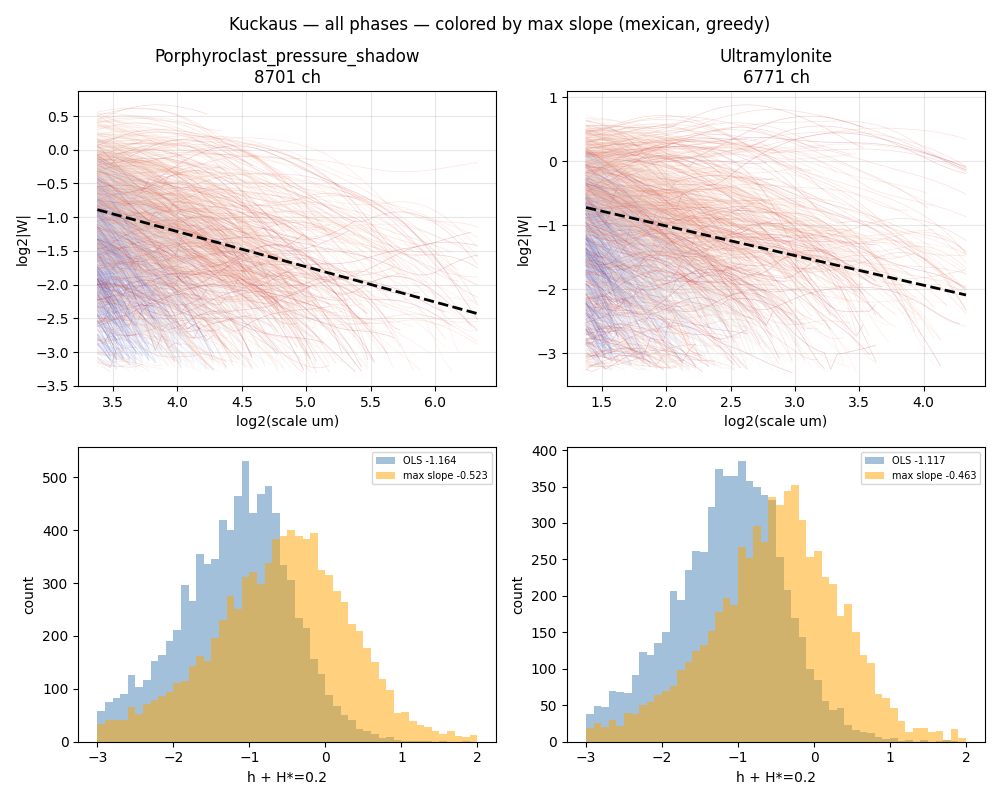


Sample                               Chains  Med OLS Med maxh
--------------------------------------------------------------
Porphyroclast_pressure_shadow          8701   -1.164   -0.523
Ultramylonite                          6771   -1.117   -0.463


In [78]:
# ===== Compare quartz log-log profiles across all 4 samples =====

def compute_holder_chainmax(chains):
    results = []
    for ch in chains:
        mod = np.abs(ch['mod']).astype(np.float64)
        log2_s = ch['log2_scales']
        if len(mod) < 3: continue
        rm = np.maximum.accumulate(mod); rm[rm == 0] = 1e-30
        A = np.vstack([log2_s, np.ones(len(log2_s))]).T
        res = np.linalg.lstsq(A, np.log2(rm), rcond=None)
        results.append({'h': res[0][0], 'x': int(ch['x'][0]), 'y': int(ch['y'][0])})
    return results

n_s = len(sample_wtmm)
fig, axes = plt.subplots(2, n_s, figsize=(5 * n_s, 8), squeeze=False)
# scales computed per-sample below

for col, (name, sw) in enumerate(sample_wtmm.items()):
    px_um = sw['px_um']
    sc = sw.get('scales', scales)
    log2_s = np.log2(np.array(sc) * px_um)  # physical um
    chains = sw['chains']
    # Compute max local slope (finite difference) per chain
    def _max_slope(ch):
        log2s = ch['log2_scales']
        log2m = ch['log2_mod']
        if len(log2s) < 2: return np.nan
        ds = np.diff(log2s); dm = np.diff(log2m)
        slopes = dm / ds
        valid = np.isfinite(slopes)
        if not valid.any(): return np.nan
        return float(np.max(slopes[valid]))

    maxh_list = [_max_slope(ch) for ch in chains]
    maxh_lookup = {}
    for i, ch in enumerate(chains):
        maxh_lookup[(int(ch['x'][0]), int(ch['y'][0]))] = maxh_list[i]
    maxh_valid = [h for h in maxh_list if np.isfinite(h)]

    ax = axes[0, col]
    if maxh_valid:
        vmin, vmax = np.percentile(maxh_valid, [5, 95])
        cm = plt.cm.coolwarm; nm = plt.Normalize(vmin, vmax)
        for ch in chains[:2000]:
            if len(ch['mod']) < 3: continue
            h = maxh_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(ch['log2_scales'] + np.log2(px_um), ch['log2_mod'], '-', color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][min(mid, len(ch['mod'])-1)] for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            h_med = np.median(maxh_valid)
            log2_s_um = log2_s
            ax.plot(log2_s_um, h_med * (log2_s_um - log2_s_um[mid]) + np.median(mods_mid), 'k--', lw=2)
    ax.set(xlabel='log2(scale um)', ylabel='log2|W|', title=f'{name}\n{len(chains)} ch')
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    h_ols = [h['h'] for h in sw['holders']]
    if h_ols:
        ax.hist(h_ols, bins=50, range=(-3, 2), alpha=0.5, label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if maxh_valid:
        ax.hist(maxh_valid, bins=50, range=(-3, 2), alpha=0.5, label=f'max slope {np.median(maxh_valid):.3f}', color='orange')
    hstar_label = f' + H*={FRACINT_ALPHA}' if FRACINT_ALPHA > 0 else ''
    ax.set(xlabel=f'h{hstar_label}', ylabel='count')
    ax.legend(fontsize=7)

plt.suptitle(f'Kuckaus — all phases — colored by max slope ({WAVELET}, {CHAIN_METHOD})', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\n{"Sample":<35} {"Chains":>7} {"Med OLS":>8} {"Med maxh":>8}')
print('-' * 62)
for name, sw in sample_wtmm.items():
    h_ols = [h['h'] for h in sw['holders']]
    mh = [_max_slope(ch) for ch in sw['chains']]
    mh = [h for h in mh if np.isfinite(h)]
    if h_ols:
        print(f'{name:<35} {len(sw["chains"]):>7d} {np.median(h_ols):>8.3f} {np.median(mh):>8.3f}')


In [79]:
# ===== Precompute partition functions for each sample =====

from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

q_list_full = np.arange(-3, 6.1, .1)
n_q = len(q_list_full)
log2c = np.log(2.0)

def build_hd_from_chains(chains, scales_list):
    n_sc = len(scales_list)
    STq_std = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlogT_std = np.zeros((n_q, n_sc), dtype=np.float64)
    STq_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlogT_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
    for ch in chains:
        n_ch = len(ch['mod']); running_max = 0.0
        for si in range(min(n_ch, n_sc)):
            m = abs(float(ch['mod'][si]))
            if m <= 0: continue
            if m > running_max: running_max = m
            log_m = np.log(m); log_m_sup = np.log(max(running_max, 1e-30))
            for qi, q in enumerate(q_list_full):
                mq = m ** q if q != 0 else 1.0
                STq_std[qi, si] += mq; STqlogT_std[qi, si] += log_m * mq
                mq_sup = running_max ** q if q != 0 else 1.0
                STq_cmax[qi, si] += mq_sup; STqlogT_cmax[qi, si] += log_m_sup * mq_sup
    def _build(STq, STqlogT):
        tau = np.full((n_q, n_sc), np.nan); h = np.full((n_q, n_sc), np.nan); D = np.full((n_q, n_sc), np.nan)
        vZ = STq > 0
        tau[vZ] = np.log(STq[vZ]) / log2c
        h[vZ] = STqlogT[vZ] / (log2c * STq[vZ])
        for qi, q in enumerate(q_list_full):
            for si in range(n_sc):
                if STq[qi, si] > 0:
                    D[qi, si] = (q * STqlogT[qi, si] - STq[qi, si] * np.log(STq[qi, si])) / (STq[qi, si] * log2c)
        return {'tau_qa': tau, 'h_qa': h, 'D_qa': D, 'q_list': q_list_full,
                'scales': np.array(scales_list), 'log2_scales': np.log2(np.array(scales_list))}
    return _build(STq_std, STqlogT_std), _build(STq_cmax, STqlogT_cmax)

sample_pf = {}
for name, sw in sample_wtmm.items():
    print(f'{name}: {len(sw["chains"])} chains...')
    sc = sw.get('scales', scales)
    px_um = sw['px_um']
    # Store physical scales in the hd dicts
    hd_s, hd_c = build_hd_from_chains(sw['chains'], sc)
    hd_s['scales_um'] = np.array(sc) * px_um
    hd_s['log2_scales_um'] = np.log2(np.array(sc) * px_um)
    hd_c['scales_um'] = np.array(sc) * px_um
    hd_c['log2_scales_um'] = np.log2(np.array(sc) * px_um)
    sample_pf[name] = {'hd_std': hd_s, 'hd_cmax': hd_c, 'chains': sw['chains']}

print('Done.')



Porphyroclast_pressure_shadow: 8701 chains...
Ultramylonite: 6771 chains...
Done.


LEFT-click = min scale | RIGHT-click = max scale


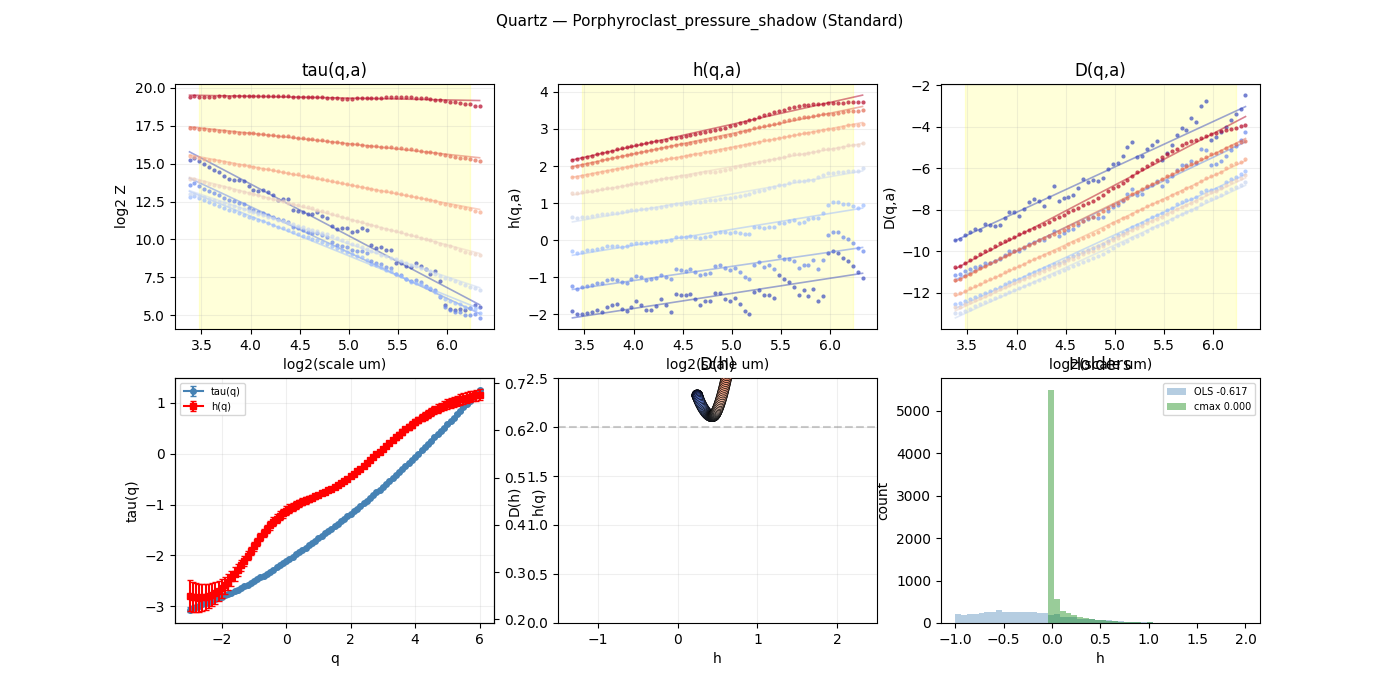

In [75]:
%matplotlib widget

pf_state = {'scale_min': None, 'scale_max': None}

sample_dd = widgets.Dropdown(options=list(sample_pf.keys()),
    description='Sample:', style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))
pf_cmax = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='PF:')

q_show = np.array([-3, -2, -1, 0,  1, 2, 3, 4])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

_fig_pf, _axes_pf = plt.subplots(2, 3, figsize=(14, 7), gridspec_kw={'height_ratios': [1, 1]})
_axes_top = _axes_pf[0]; _ax_tau = _axes_pf[1, 0]; _ax_dh = _axes_pf[1, 1]; _ax_hist = _axes_pf[1, 2]
_twin = [None]

def _pf_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_top: return
    a = 2 ** event.xdata
    if event.button == 1: pf_state['scale_min'] = a
    elif event.button == 3: pf_state['scale_max'] = a
    if pf_state['scale_min'] and pf_state['scale_max'] and pf_state['scale_min'] > pf_state['scale_max']:
        pf_state['scale_min'], pf_state['scale_max'] = pf_state['scale_max'], pf_state['scale_min']
    pf_draw()
_fig_pf.canvas.mpl_connect('button_press_event', _pf_click)

def pf_draw(*_):
    name = sample_dd.value
    # Reset scale range when switching samples (different px_um = different um ranges)
    sw = sample_wtmm.get(name, {})
    px_um = sw.get('px_um', 0.8)
    sc = sw.get('scales', [7, 100])
    sc_um = np.array(sc) * px_um
    if pf_state['scale_min'] is None or pf_state['scale_min'] < sc_um[0] * 0.5 or pf_state['scale_min'] > sc_um[-1] * 2:
        pf_state['scale_min'] = sc_um[2] if len(sc_um) > 2 else sc_um[0]
    if pf_state['scale_max'] is None or pf_state['scale_max'] < sc_um[0] * 0.5 or pf_state['scale_max'] > sc_um[-1] * 2:
        pf_state['scale_max'] = sc_um[-3] if len(sc_um) > 3 else sc_um[-1]
    v = sample_pf[name]
    hd = v['hd_std'] if 'Standard' in pf_cmax.value else v['hd_cmax']
    chains = v['chains']; # Use physical scales (um) if available, else pixel scales
    if 'log2_scales_um' in hd:
        log2_s = hd['log2_scales_um']; scales_arr = hd['scales_um']
    else:
        log2_s = hd['log2_scales']; scales_arr = hd['scales']
    if pf_state['scale_min'] is None: pf_state['scale_min'] = scales_arr[2]
    if pf_state['scale_max'] is None: pf_state['scale_max'] = scales_arr[-3]
    smin, smax = pf_state['scale_min'], pf_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([('tau_qa','log2 Z','tau(q,a)'),('h_qa','h(q,a)','h(q,a)'),('D_qa','D(q,a)','D(q,a)')]):
        ax = _axes_top[panel]
        for qi_val, color in zip(q_show, colors_q):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val)); y = hd[key][idx]; valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    ax.plot(log2_s[valid], sl*log2_s[valid]+ic, '-', color=color, lw=1.2, alpha=0.5)
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.set(xlabel='log2(scale um)', ylabel=ylabel, title=title); ax.grid(True, alpha=0.2)

    _ax_tau.cla()
    if _twin[0]: _twin[0].remove(); _twin[0] = None
    _ax_dh.cla(); _ax_hist.cla()
    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']; valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])
        if valid.any():
            _ax_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid], fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
            _ax_tau.set(xlabel='q', ylabel='tau(q)'); _ax_tau.grid(True, alpha=0.2)
            ax2 = _ax_tau.twinx(); _twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid], fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
            ax2.set(ylabel='h(q)')
            l1, lb1 = _ax_tau.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
            _ax_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=7)
            _ax_dh.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm', s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_dh.axhline(2, color='gray', ls='--', alpha=0.4)
            pk = np.argmax(res['D'][valid])
            _ax_dh.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
            _ax_dh.annotate(f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                xy=(res['h'][valid][pk], res['D'][valid][pk]),
                xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                bbox=dict(boxstyle='round', fc='lightyellow'))
            _ax_dh.set(xlabel='h', ylabel='D(h)', title='D(h)', xlim=(-1.5, 2.5), ylim=(0, 2.5))
            _ax_dh.grid(True, alpha=0.2)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cm = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols: _ax_hist.hist(h_ols, bins=50, range=(-1, 2), alpha=0.4, label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cm: _ax_hist.hist(h_cm, bins=50, range=(-1, 2), alpha=0.4, label=f'cmax {np.median(h_cm):.3f}', color='green')
    _ax_hist.set(xlabel='h', ylabel='count', title='Holders'); _ax_hist.legend(fontsize=7)
    _fig_pf.suptitle(f'Quartz — {name} ({pf_cmax.value})', fontsize=11)
    _fig_pf.canvas.draw_idle()

sample_dd.observe(pf_draw, names='value'); pf_cmax.observe(pf_draw, names='value')
print('LEFT-click = min scale | RIGHT-click = max scale')
display(widgets.HBox([sample_dd, pf_cmax]))
pf_draw()



Porphyroclast_pressure_shadow: done
Ultramylonite: done
LEFT-click C0/C1 or C2/C3 panels = fit min | RIGHT-click = fit max


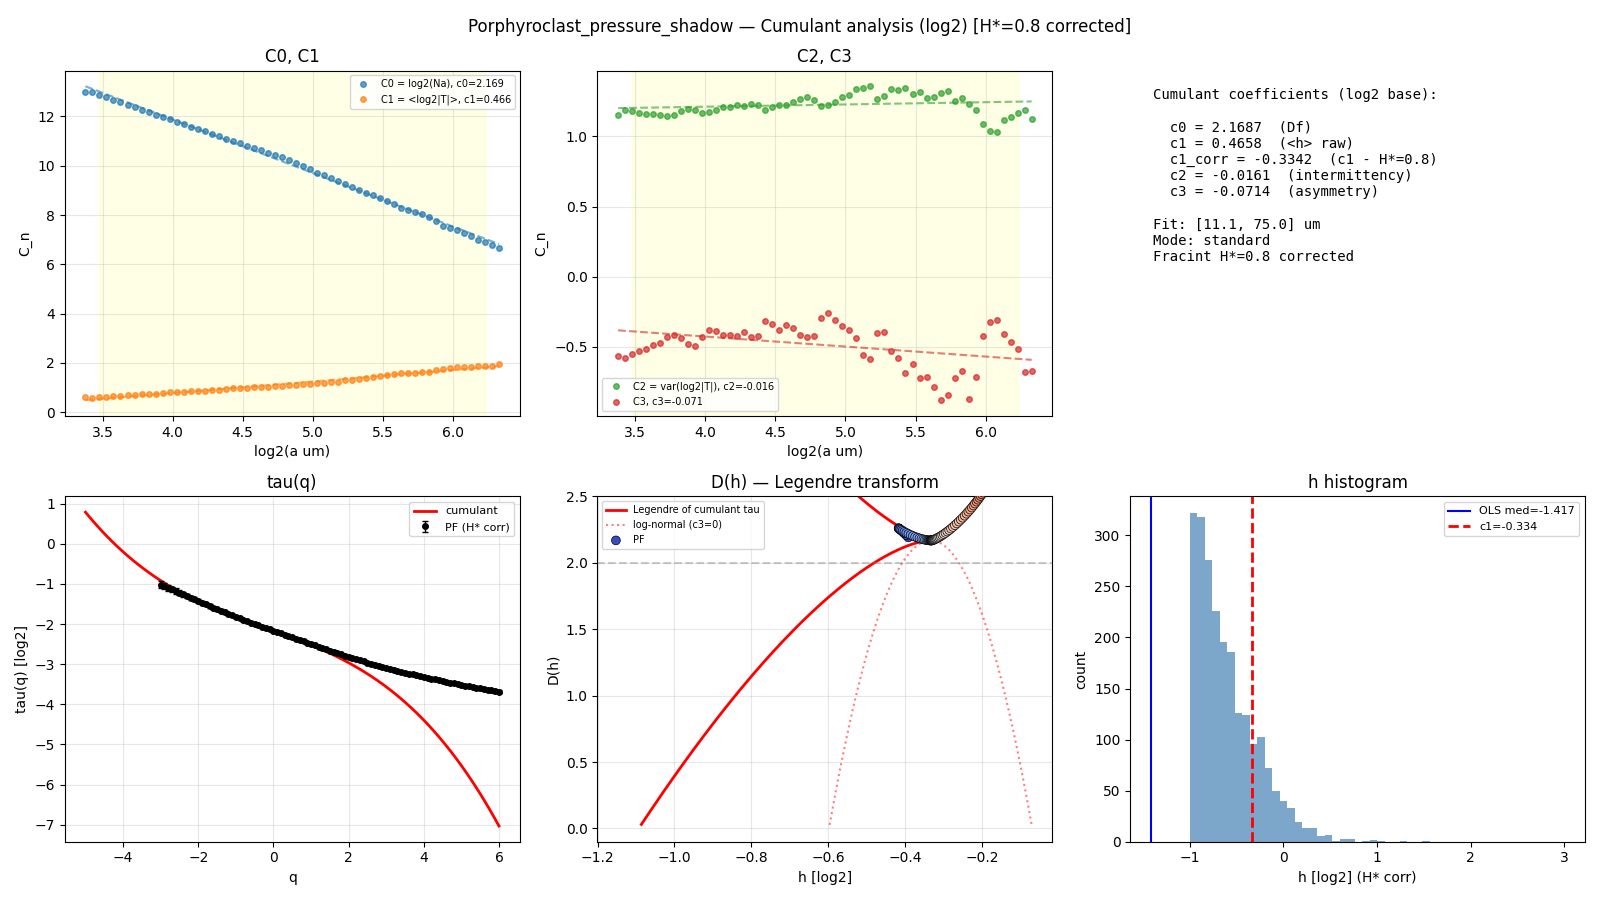

In [76]:
# ===== Cumulant analysis (Venugopal, Roux, Foufoula-Georgiou & Arneodo 2005) =====
# Eq 7: Psi_a(q) = ln<exp(q*ln|T_a|)> = sum C_n(a) * q^n / n!
# Eq 9: C_n(a) = (-1)^{n-1} * c_n * log(a)   [any log base]
# Eq 8: tau(q) = -c0 + c1*q - c2*q^2/2 + c3*q^3/6 + ...
# D(h) via Legendre transform of smooth tau(q), NOT the log-normal approximation.
# If FRACINT_ALPHA > 0, correct c1 by subtracting H* before plotting.
#
# All in log2 base throughout.

from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

def compute_cumulants_log2(chains, scales, use_chainmax=False):
    """Compute cumulants of log2|T_a| at each scale."""
    n_sc = len(scales)
    log2mod_per_scale = [[] for _ in range(n_sc)]
    for ch in chains:
        rm = 0.0
        for si in range(min(len(ch['mod']), n_sc)):
            m = abs(float(ch['mod'][si]))
            if m <= 0: continue
            if use_chainmax:
                if m > rm: rm = m
                m = rm
            log2mod_per_scale[si].append(np.log2(m))
    C = np.full((4, n_sc), np.nan)
    for si in range(n_sc):
        v = np.array(log2mod_per_scale[si])
        n = len(v)
        if n < 5: continue
        C[0, si] = np.log2(n)
        C[1, si] = np.mean(v)
        C[2, si] = np.var(v)
        C[3, si] = np.mean((v - np.mean(v))**3)
    return C

# Precompute for each sample
sample_cum = {}
for name, sw in sample_wtmm.items():
    sc = sw.get('scales', scales)
    px_um = sw['px_um']
    sc_um = np.array(sc) * px_um
    C_std = compute_cumulants_log2(sw['chains'], sc, use_chainmax=False)
    C_cmax = compute_cumulants_log2(sw['chains'], sc, use_chainmax=True)
    sample_cum[name] = {'C_std': C_std, 'C_cmax': C_cmax, 'scales_um': sc_um, 'px_um': px_um}
    print(f'{name}: done')

# --- Interactive viewer ---
cum_dd = widgets.Dropdown(options=list(sample_cum.keys()),
    description='Sample:', style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))
cum_cmax = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='PF:')

cum_states = {}  # per-sample: {name: {'fit_min': ..., 'fit_max': ...}}
_fig_cum, _axes_cum = plt.subplots(2, 3, figsize=(16, 9))

def _cum_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in [_axes_cum[0, 0], _axes_cum[0, 1]]: return
    name = cum_dd.value
    st = cum_states.setdefault(name, {'fit_min': None, 'fit_max': None})
    a_val = 2 ** event.xdata
    if event.button == 1: st['fit_min'] = a_val
    elif event.button == 3: st['fit_max'] = a_val
    if (st['fit_min'] and st['fit_max'] and st['fit_min'] > st['fit_max']):
        st['fit_min'], st['fit_max'] = st['fit_max'], st['fit_min']
    cum_draw()
_fig_cum.canvas.mpl_connect('button_press_event', _cum_click)

def cum_draw(*_):
    name = cum_dd.value
    cd = sample_cum[name]
    use_cmax = 'Chainmax' in cum_cmax.value
    C = cd['C_cmax'] if use_cmax else cd['C_std']
    sc_um = cd['scales_um']
    log2_a = np.log2(sc_um)

    st = cum_states.setdefault(name, {'fit_min': None, 'fit_max': None})
    if st['fit_min'] is None or st['fit_min'] < sc_um[0]*0.5 or st['fit_min'] > sc_um[-1]*2:
        st['fit_min'] = sc_um[2] if len(sc_um) > 2 else sc_um[0]
    if st['fit_max'] is None or st['fit_max'] < sc_um[0]*0.5 or st['fit_max'] > sc_um[-1]*2:
        st['fit_max'] = sc_um[-3] if len(sc_um) > 3 else sc_um[-1]
    fmin, fmax = st['fit_min'], st['fit_max']
    fmask = (sc_um >= fmin) & (sc_um <= fmax)

    # Fit slopes of C_n vs log2(a)
    c = {}
    slopes = {}
    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    for n in range(4):
        y = C[n]; v = np.isfinite(y) & fmask
        if v.sum() < 3:
            c[n] = np.nan; slopes[n] = np.nan
            continue
        sl, ic = np.polyfit(log2_a[v], y[v], 1)
        slopes[n] = sl
        c[n] = sign_map[n] * sl

    c0, c1, c2, c3 = c[0], c[1], c[2], c[3]
    c2_abs = abs(c2) if np.isfinite(c2) else 0.001

    # Fractional integration correction: tau(q) of integrated signal = tau_orig + H*·q
    # So measured c1 = c1_true + H*. Subtract to recover intrinsic spectrum.
    Hstar = FRACINT_ALPHA  # from cell 9
    c1_corr = c1 - Hstar if np.isfinite(c1) else np.nan

    for ax in _axes_cum.flat: ax.cla()

    # Top left: C0, C1
    ax = _axes_cum[0, 0]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    names_c = ['C0 = log2(Na)', 'C1 = <log2|T|>', 'C2 = var(log2|T|)', 'C3']
    for n in [0, 1]:
        y = C[n]; v = np.isfinite(y)
        if v.any():
            ax.plot(log2_a[v], y[v], 'o', color=colors[n], ms=4, alpha=0.7,
                    label=f'{names_c[n]}, c{n}={c[n]:.3f}')
            vm = v & fmask
            if vm.sum() >= 2:
                ax.plot(log2_a[v], slopes[n]*log2_a[v] + (np.mean(y[vm]) - slopes[n]*np.mean(log2_a[vm])),
                        '--', color=colors[n], lw=1.5, alpha=0.6)
    ax.axvspan(np.log2(fmin), np.log2(fmax), alpha=0.1, color='yellow')
    ax.set(xlabel='log2(a um)', ylabel='C_n', title='C0, C1'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Top middle: C2, C3
    ax = _axes_cum[0, 1]
    for n in [2, 3]:
        y = C[n]; v = np.isfinite(y)
        if v.any():
            ax.plot(log2_a[v], y[v], 'o', color=colors[n], ms=4, alpha=0.7,
                    label=f'{names_c[n]}, c{n}={c[n]:.3f}')
            vm = v & fmask
            if vm.sum() >= 2:
                ax.plot(log2_a[v], slopes[n]*log2_a[v] + (np.mean(y[vm]) - slopes[n]*np.mean(log2_a[vm])),
                        '--', color=colors[n], lw=1.5, alpha=0.6)
    ax.axvspan(np.log2(fmin), np.log2(fmax), alpha=0.1, color='yellow')
    ax.set(xlabel='log2(a um)', ylabel='C_n', title='C2, C3'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Top right: summary
    ax = _axes_cum[0, 2]; ax.axis('off')
    txt = (f'Cumulant coefficients (log2 base):\n\n'
           f'  c0 = {c0:.4f}  (Df)\n'
           f'  c1 = {c1:.4f}  (<h> raw)\n')
    if Hstar > 0:
        txt += f'  c1_corr = {c1_corr:.4f}  (c1 - H*={Hstar})\n'
    txt += (f'  c2 = {c2:.4f}  (intermittency)\n'
            f'  c3 = {c3:.4f}  (asymmetry)\n\n'
            f'Fit: [{fmin:.1f}, {fmax:.1f}] um\n'
            f'Mode: {"chainmax" if use_cmax else "standard"}')
    if Hstar > 0:
        txt += f'\nFracint H*={Hstar} corrected'
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top', fontsize=10, family='monospace')

    # Bottom left: tau(q) — corrected for fracint
    ax = _axes_cum[1, 0]
    q_arr = np.linspace(-5, 6, 300)
    # tau with fracint correction: subtract H*·q
    tau_cum = -c0 + c1_corr*q_arr - c2_abs*q_arr**2/2 + c3*q_arr**3/6
    if np.any(np.isfinite(tau_cum)):
        ax.plot(q_arr, tau_cum, 'r-', lw=2, label='cumulant')
    # PF overlay (PF tau already includes fracint effect, so correct it too)
    pf = sample_pf.get(name)
    if pf:
        hd = pf['hd_cmax'] if use_cmax else pf['hd_std']
        px_um_l = cd['px_um']
        try:
            res = extract_hq_Dq_from_plateaus(hd, scale_range=(fmin/px_um_l, fmax/px_um_l))
            v = np.isfinite(res['tau'])
            if v.any():
                tau_pf_corr = res['tau'][v] - Hstar * res['q_list'][v]
                ax.errorbar(res['q_list'][v], tau_pf_corr, yerr=res['tau_err'][v],
                           fmt='ko', ms=4, capsize=2, lw=1, label='PF' + (' (H* corr)' if Hstar > 0 else ''))
        except: pass
    ax.set(xlabel='q', ylabel='tau(q) [log2]', title='tau(q)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Bottom middle: D(h) via Legendre transform of smooth tau(q)
    ax = _axes_cum[1, 1]
    q_leg = np.linspace(-5, 6, 500)
    # h(q) = dtau/dq = c1 - c2*q + c3*q^2/2  (using corrected c1)
    h_leg = c1_corr - c2_abs*q_leg + c3*q_leg**2/2
    # tau(q) = -c0 + c1*q - c2*q^2/2 + c3*q^3/6
    tau_leg = -c0 + c1_corr*q_leg - c2_abs*q_leg**2/2 + c3*q_leg**3/6
    # D(q) = q*h(q) - tau(q)
    D_leg = q_leg * h_leg - tau_leg
    # Clip for display
    show = (D_leg >= 0) & np.isfinite(h_leg) & np.isfinite(D_leg)
    if show.any():
        ax.plot(h_leg[show], D_leg[show], 'r-', lw=2, label='Legendre of cumulant tau')
    # Log-normal parabola for reference
    if c2_abs > 1e-10:
        dh_sp = np.sqrt(2*c0*c2_abs) if c0*c2_abs > 0 else 1.0
        h_par = np.linspace(c1_corr - dh_sp*1.05, c1_corr + dh_sp*1.05, 300)
        D_par = c0 - (h_par - c1_corr)**2 / (2*c2_abs)
        D_par = np.where(D_par >= 0, D_par, np.nan)
        ax.plot(h_par, D_par, 'r:', lw=1.5, alpha=0.5, label='log-normal (c3=0)')
    # PF overlay
    if pf:
        hd = pf['hd_cmax'] if use_cmax else pf['hd_std']
        try:
            res = extract_hq_Dq_from_plateaus(hd, scale_range=(fmin/px_um_l, fmax/px_um_l))
            v = np.isfinite(res['h']) & np.isfinite(res['D'])
            if v.any():
                h_pf_corr = res['h'][v] - Hstar  # shift h by -H*
                ax.scatter(h_pf_corr, res['D'][v], c=res['q_list'][v], cmap='coolwarm',
                          s=40, edgecolors='black', linewidths=0.5, zorder=5, label='PF')
        except: pass
    ax.axhline(2, color='gray', ls='--', alpha=0.4)
    ax.set(xlabel='h [log2]', ylabel='D(h)', title='D(h) — Legendre transform', ylim=(-0.1, 2.5))
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Bottom right: h histogram
    ax = _axes_cum[1, 2]
    sw = sample_wtmm.get(name, {})
    h_vals = np.array([h['h'] for h in sw.get('holders', [])])
    if len(h_vals):
        h_vals_corr = h_vals - Hstar
        ax.hist(h_vals_corr, bins=50, range=(-1, 3), alpha=0.7, color='steelblue')
        ax.axvline(np.median(h_vals_corr), color='blue', lw=1.5,
                   label=f'OLS med={np.median(h_vals_corr):.3f}')
    if np.isfinite(c1_corr):
        ax.axvline(c1_corr, color='red', ls='--', lw=2, label=f'c1={c1_corr:.3f}')
    ax.set(xlabel='h [log2]' + (' (H* corr)' if Hstar > 0 else ''), ylabel='count', title='h histogram')
    ax.legend(fontsize=8)

    _fig_cum.suptitle(f'{name} — Cumulant analysis (log2)' + (f' [H*={Hstar} corrected]' if Hstar > 0 else ''), fontsize=12)
    _fig_cum.tight_layout()
    _fig_cum.canvas.draw_idle()

cum_dd.observe(cum_draw, names='value')
cum_cmax.observe(cum_draw, names='value')
print('LEFT-click C0/C1 or C2/C3 panels = fit min | RIGHT-click = fit max')
display(widgets.HBox([cum_dd, cum_cmax]))
cum_draw()



LEFT-click tau(q,a) panel = min scale | RIGHT-click = max scale


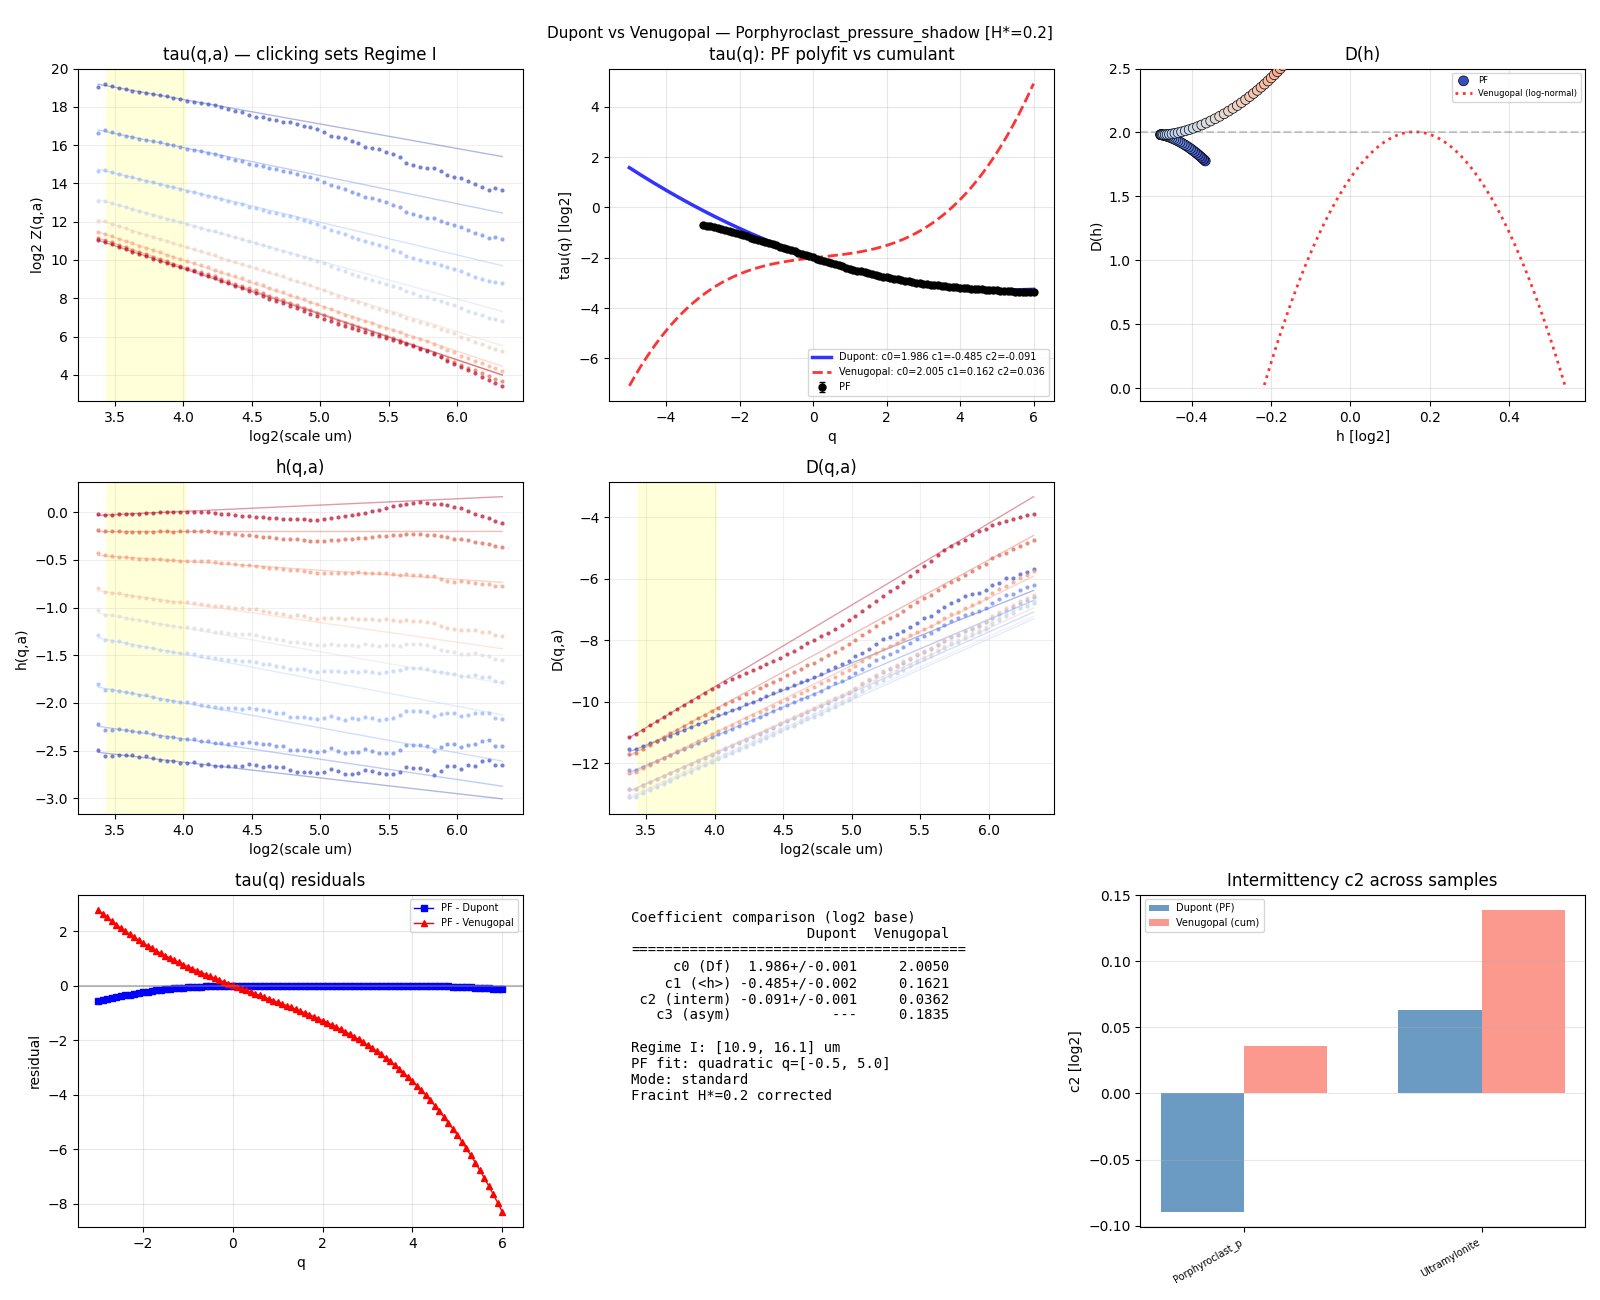

In [80]:
# ===== Dupont/Arneodo PF polynomial fit vs Venugopal cumulants =====
# Both methods in log2 base. D(h) via Legendre transform (not log-normal approx).
# Fractional integration H* correction applied to both.

from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

%matplotlib widget

pf_poly_dd = widgets.Dropdown(options=list(sample_pf.keys()),
    description='Sample:', style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))
pf_poly_cmax = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='PF:')
pf_poly_qrange = widgets.FloatRangeSlider(value=[-0.5, 5.0], min=-5.0, max=6.0, step=0.25,
    description='q range:', style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))
pf_poly_regime2 = widgets.Checkbox(value=False, description='Regime II',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='130px'))
pf_poly_regime_click = widgets.ToggleButtons(options=['I', 'II'], value='I',
    description='Click sets:', style={'description_width': 'initial'}, layout=widgets.Layout(width='200px'))

_fig_comp, _axes_comp = plt.subplots(3, 3, figsize=(16, 13))

poly_states = {}  # per-sample: {name: {'scale_min': ..., 'scale_max': ..., 'qmin': -0.5, 'qmax': 5.0}}
_prev_poly_sample = [None]

def _poly_default(name):
    """Default state for a sample, syncing from cumulant cell if available."""
    cs = cum_states.get(name, {})
    return {'scale_min': cs.get('fit_min'), 'scale_max': cs.get('fit_max'),
            'scale_min_2': None, 'scale_max_2': None,
            'qmin': -0.5, 'qmax': 5.0}

def _poly_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in [_axes_comp[0, 0]]: return
    name = pf_poly_dd.value
    st = poly_states.setdefault(name, _poly_default(name))
    a = 2 ** event.xdata
    regime = pf_poly_regime_click.value
    if regime == 'I':
        if event.button == 1: st['scale_min'] = a
        elif event.button == 3: st['scale_max'] = a
        if (st['scale_min'] and st['scale_max'] and st['scale_min'] > st['scale_max']):
            st['scale_min'], st['scale_max'] = st['scale_max'], st['scale_min']
    else:  # II
        if event.button == 1: st['scale_min_2'] = a
        elif event.button == 3: st['scale_max_2'] = a
        if (st['scale_min_2'] and st['scale_max_2'] and st['scale_min_2'] > st['scale_max_2']):
            st['scale_min_2'], st['scale_max_2'] = st['scale_max_2'], st['scale_min_2']
    poly_draw()
_fig_comp.canvas.mpl_connect('button_press_event', _poly_click)

def _legendre_Dh(c0, c1, c2, c3, q_range=(-5, 6), n_pts=500):
    """Parametric D(h) via Legendre transform of tau(q) = -c0 + c1*q - c2*q^2/2 + c3*q^3/6."""
    q = np.linspace(q_range[0], q_range[1], n_pts)
    h = c1 - c2*q + c3*q**2/2
    tau = -c0 + c1*q - c2*q**2/2 + c3*q**3/6
    D = q*h - tau
    return h, D

def poly_draw(*_):
    name = pf_poly_dd.value
    use_cmax = 'Chainmax' in pf_poly_cmax.value
    Hstar = FRACINT_ALPHA

    # --- Get PF data ---
    pf = sample_pf[name]
    hd = pf['hd_cmax'] if use_cmax else pf['hd_std']
    sw = sample_wtmm[name]
    px_um = sw['px_um']
    sc = sw.get('scales', [])
    sc_um = np.array(sc) * px_um

    st = poly_states.setdefault(name, _poly_default(name))
    # Only sync slider when sample changes (not when slider itself triggers redraw)
    if name != _prev_poly_sample[0]:
        _prev_poly_sample[0] = name
        pf_poly_qrange.unobserve(poly_draw, names='value')
        pf_poly_qrange.value = (st.get('qmin', -0.5), st.get('qmax', 5.0))
        pf_poly_qrange.observe(poly_draw, names='value')
    # Auto-reset scale bounds
    if st['scale_min'] is None or st['scale_min'] < sc_um[0]*0.5 or st['scale_min'] > sc_um[-1]*2:
        st['scale_min'] = sc_um[2] if len(sc_um) > 2 else sc_um[0]
    if st['scale_max'] is None or st['scale_max'] < sc_um[0]*0.5 or st['scale_max'] > sc_um[-1]*2:
        st['scale_max'] = sc_um[-3] if len(sc_um) > 3 else sc_um[-1]
    smin, smax = st['scale_min'], st['scale_max']
    smin2 = st.get('scale_min_2'); smax2 = st.get('scale_max_2')
    has_regime2 = pf_poly_regime2.value and smin2 is not None and smax2 is not None

    # Extract tau(q) from PF — correct for fracint
    res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin/px_um, smax/px_um))
    q_pf = res['q_list']
    tau_pf = res['tau'] - Hstar * q_pf  # fracint correction
    tau_err = res['tau_err']
    h_pf = res['h'] - Hstar             # fracint correction
    D_pf = res['D']                     # D unchanged by fracint
    valid = np.isfinite(tau_pf) & np.isfinite(h_pf) & np.isfinite(D_pf)

    # --- Method 1: Dupont polynomial fit of corrected PF tau(q) ---
    qmin, qmax = pf_poly_qrange.value
    st['qmin'] = qmin; st['qmax'] = qmax
    fit_mask = valid & (q_pf >= qmin) & (q_pf <= qmax)
    c0_pf = c1_pf = c2_pf = np.nan
    c0_err = c1_err = c2_err = np.nan
    if fit_mask.sum() >= 4:
        # Weighted fit: w = 1/sigma_tau (Dupont-style)
        w = np.ones(fit_mask.sum())
        te = tau_err[fit_mask]
        good_err = np.isfinite(te) & (te > 0)
        if good_err.any():
            w[good_err] = 1.0 / te[good_err]
        p, cov = np.polyfit(q_pf[fit_mask], tau_pf[fit_mask], 2, w=w, cov=True)
        c0_pf = -p[2]; c1_pf = p[1]; c2_pf = -2 * p[0]
        # Propagate errors: p = [a2, a1, a0], c0=-a0, c1=a1, c2=-2*a2
        c0_err = np.sqrt(cov[2, 2])
        c1_err = np.sqrt(cov[1, 1])
        c2_err = 2 * np.sqrt(cov[0, 0])

    # --- Regime II fit (if set) ---
    c0_pf2 = c1_pf2 = c2_pf2 = np.nan
    c0_e2 = c1_e2 = c2_e2 = np.nan
    if has_regime2:
        res2 = extract_hq_Dq_from_plateaus(hd, scale_range=(smin2/px_um, smax2/px_um))
        tau_pf2 = res2['tau'] - Hstar * res2['q_list']
        tau_err2 = res2['tau_err']
        h_pf2 = res2['h'] - Hstar
        D_pf2 = res2['D']
        valid2 = np.isfinite(tau_pf2) & np.isfinite(h_pf2) & np.isfinite(D_pf2)
        fit_mask2 = valid2 & (res2['q_list'] >= qmin) & (res2['q_list'] <= qmax)
        if fit_mask2.sum() >= 4:
            w2 = np.ones(fit_mask2.sum())
            te2 = tau_err2[fit_mask2]
            ge2 = np.isfinite(te2) & (te2 > 0)
            if ge2.any(): w2[ge2] = 1.0 / te2[ge2]
            p2, cov2 = np.polyfit(res2['q_list'][fit_mask2], tau_pf2[fit_mask2], 2, w=w2, cov=True)
            c0_pf2 = -p2[2]; c1_pf2 = p2[1]; c2_pf2 = -2*p2[0]
            c0_e2 = np.sqrt(cov2[2,2]); c1_e2 = np.sqrt(cov2[1,1]); c2_e2 = 2*np.sqrt(cov2[0,0])

    # --- Method 2: Venugopal cumulant (already in log2, apply fracint correction) ---
    cd = sample_cum[name]
    C = cd['C_cmax'] if use_cmax else cd['C_std']
    sc_um_cum = cd['scales_um']
    log2_a = np.log2(sc_um_cum)
    fmask = (sc_um_cum >= smin) & (sc_um_cum <= smax)

    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c_ven = {}
    for n in range(4):
        y = C[n]; v = np.isfinite(y) & fmask
        if v.sum() < 3:
            c_ven[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[v], y[v], 1)
        c_ven[n] = sign_map[n] * sl
    c0_v = c_ven[0]
    c1_v = (c_ven[1] - Hstar) if np.isfinite(c_ven.get(1, np.nan)) else np.nan
    c2_v = abs(c_ven[2]) if np.isfinite(c_ven.get(2, np.nan)) else np.nan
    c3_v = c_ven[3] if np.isfinite(c_ven.get(3, np.nan)) else np.nan

    for ax in _axes_comp.flat: ax.cla()

    # --- Top left: tau(q,a) with scale range ---
    ax = _axes_comp[0, 0]
    log2_s = hd.get('log2_scales_um', hd['log2_scales'])
    scales_arr = hd.get('scales_um', hd['scales'])
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)
    q_show_l = np.array([-3, -2, -1, 0, 1, 2, 3, 4])
    colors_ql = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_l)))
    for qi_val, color in zip(q_show_l, colors_ql):
        idx = np.argmin(np.abs(hd['q_list'] - qi_val))
        y = hd['tau_qa'][idx]; v2 = np.isfinite(y)
        if v2.sum() < 2: continue
        ax.plot(log2_s[v2], y[v2], 'o', color=color, ms=3, alpha=0.7, mec='none')
        yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
        if vf.sum() >= 2:
            try:
                sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                ax.plot(log2_s[v2], sl*log2_s[v2]+ic, '-', color=color, lw=1, alpha=0.4)
            except: pass
    ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
    if has_regime2:
        ax.axvspan(np.log2(smin2), np.log2(smax2), alpha=0.15, color='cyan', zorder=0)
    regime_label = 'Regime ' + pf_poly_regime_click.value
    ax.set(xlabel='log2(scale um)', ylabel='log2 Z(q,a)',
           title=f'tau(q,a) — clicking sets {regime_label}')
    ax.grid(True, alpha=0.2)

    # === Middle row: h(q,a) and D(q,a) ===
    q_show_l2 = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
    colors_ql2 = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_l2)))
    for panel_idx, (key, ylabel, title) in enumerate([('h_qa', 'h(q,a)', 'h(q,a)'),
                                                        ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_comp[1, panel_idx]
        for qi_val, color in zip(q_show_l2, colors_ql2):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]; v2 = np.isfinite(y)
            if v2.sum() < 2: continue
            ax.plot(log2_s[v2], y[v2], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    ax.plot(log2_s[v2], sl*log2_s[v2]+ic, '-', color=color, lw=1, alpha=0.4)
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        if has_regime2:
            ax.axvspan(np.log2(smin2), np.log2(smax2), alpha=0.15, color='cyan', zorder=0)
        ax.set(xlabel='log2(scale um)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    # Empty panel [1,2] for now
    _axes_comp[1, 2].axis('off')

    # --- Top middle: tau(q) comparison ---
    ax = _axes_comp[0, 1]
    q_dense = np.linspace(-5, 6, 300)
    if valid.any():
        ax.errorbar(q_pf[valid], tau_pf[valid], yerr=tau_err[valid],
                    fmt='ko', ms=5, capsize=2, lw=1, label='PF', zorder=5)
    if np.isfinite(c0_pf):
        tau_dupont = -c0_pf + c1_pf*q_dense - c2_pf*q_dense**2/2
        ax.plot(q_dense, tau_dupont, 'b-', lw=2.5, alpha=0.8,
                label=f'Dupont: c0={c0_pf:.3f} c1={c1_pf:.3f} c2={c2_pf:.3f}')
    if np.isfinite(c0_v):
        tau_ven = -c0_v + c1_v*q_dense - c2_v*q_dense**2/2 + c3_v*q_dense**3/6
        ax.plot(q_dense, tau_ven, 'r--', lw=2, alpha=0.8,
                label=f'Venugopal: c0={c0_v:.3f} c1={c1_v:.3f} c2={c2_v:.3f}')
    if has_regime2 and np.isfinite(c0_pf2):
        ax.plot(q_dense, -c0_pf2 + c1_pf2*q_dense - c2_pf2*q_dense**2/2,
                'b--', lw=1.5, alpha=0.6, label=f'Regime II c2={c2_pf2:.3f}')
        if valid2.any():
            ax.errorbar(res2['q_list'][valid2], tau_pf2[valid2], yerr=tau_err2[valid2],
                        fmt='s', ms=4, capsize=2, lw=1, mfc='none', mec='cornflowerblue',
                        ecolor='cornflowerblue', zorder=4, label='PF (II)')
    ax.set(xlabel='q', ylabel='tau(q) [log2]', title='tau(q): PF polyfit vs cumulant')
    ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

    # Phase transition check (Dupont eq 4.1-4.2)
    # Detect tau_sat from PF points beyond qmax where tau FLATTENS.
    # Saturation = tau slope much less steep than quadratic predicts at high q.
    # Only accept positive q_crit (multifractal→fractal at strong singularities).
    _tau_sat = _q_crit = _h_crit = np.nan
    if np.isfinite(c0_pf) and np.isfinite(c1_pf) and c2_pf > 1e-6:
        sat_mask = valid & (q_pf > qmax)
        if sat_mask.sum() >= 3:
            q_sat = q_pf[sat_mask]; tau_sat_pts = tau_pf[sat_mask]
            # Check flattening: actual slope at high q vs quadratic's predicted slope
            srt = np.argsort(q_sat)
            actual_slope = np.polyfit(q_sat[srt], tau_sat_pts[srt], 1)[0]
            predicted_slope = c1_pf - c2_pf * np.mean(q_sat)  # dtau/dq at mean high q
            # Saturated if actual slope is much flatter than predicted
            if abs(actual_slope) < abs(predicted_slope) * 0.5:
                _tau_sat = np.mean(tau_sat_pts)
                disc = (c1_pf/c2_pf)**2 + 2*(-_tau_sat - c0_pf)/c2_pf
                if disc >= 0:
                    qc = c1_pf/c2_pf - np.sqrt(disc)
                    if qc > 0:  # only positive q_crit (strong singularity transition)
                        _q_crit = qc
                        _h_crit = c1_pf - c2_pf * _q_crit

    # --- Top right: D(h) ---
    ax = _axes_comp[0, 2]
    if valid.any():
        ax.scatter(h_pf[valid], D_pf[valid], c=q_pf[valid], cmap='coolwarm',
                  s=50, edgecolors='black', linewidths=0.5, zorder=5, label='PF')
    if np.isfinite(c0_pf) and c2_pf > 1e-6:
        dh_span = np.sqrt(2*c0_pf*c2_pf) if c0_pf*c2_pf > 0 else 1.0
        h_d = np.linspace(c1_pf - dh_span*1.05, c1_pf + dh_span*1.05, 300)
        D_d = c0_pf - (h_d - c1_pf)**2 / (2*c2_pf)
        D_d = np.where(D_d >= 0, D_d, np.nan)
        ax.plot(h_d, D_d, 'b-', lw=2.5, alpha=0.8, label='Dupont')
        # Mark h_min, h_max where D=0
        h_min_d = c1_pf - dh_span; h_max_d = c1_pf + dh_span
        ax.plot([h_min_d, h_max_d], [0, 0], 'bv', ms=6, zorder=6)
        ax.annotate(f'h_min={h_min_d:.2f}', xy=(h_min_d, 0), xytext=(h_min_d-0.1, 0.15),
                    fontsize=7, color='blue', ha='right')
        ax.annotate(f'h_max={h_max_d:.2f}', xy=(h_max_d, 0), xytext=(h_max_d+0.1, 0.15),
                    fontsize=7, color='blue')
    if np.isfinite(c0_v) and c2_v > 1e-6:
        dh_span_v = np.sqrt(2*c0_v*c2_v) if c0_v*c2_v > 0 else 1.0
        h_par = np.linspace(c1_v - dh_span_v*1.05, c1_v + dh_span_v*1.05, 300)
        D_par = c0_v - (h_par - c1_v)**2 / (2*c2_v)
        D_par = np.where(D_par >= 0, D_par, np.nan)
        ax.plot(h_par, D_par, 'r:', lw=2, alpha=0.8, label='Venugopal (log-normal)')
    # Regime II D(h) parabola
    if has_regime2 and np.isfinite(c0_pf2) and c2_pf2 > 1e-6:
        dh_sp2 = np.sqrt(2*c0_pf2*c2_pf2) if c0_pf2*c2_pf2 > 0 else 1.0
        h_d2 = np.linspace(c1_pf2 - dh_sp2, c1_pf2 + dh_sp2, 300)
        D_d2 = c0_pf2 - (h_d2 - c1_pf2)**2/(2*c2_pf2)
        ax.plot(h_d2, np.where(D_d2 >= 0, D_d2, np.nan), 'b--', lw=1.5, alpha=0.6, label='Regime II')
        if valid2.any():
            ax.scatter(h_pf2[valid2], D_pf2[valid2], c=res2['q_list'][valid2], cmap='coolwarm',
                      s=30, edgecolors='cornflowerblue', linewidths=1, zorder=4, marker='s')
    # Phase transition tangent line (Dupont Fig 5e)
    # D_II(h) = -tau_sat + q_crit * h for h < h_crit
    if np.isfinite(_q_crit) and np.isfinite(_tau_sat):
        h_tang = np.linspace(-0.5, _h_crit + 0.2, 100)
        D_tang = -_tau_sat + _q_crit * h_tang
        D_tang = np.where(D_tang >= 0, D_tang, np.nan)
        ax.plot(h_tang, D_tang, 'k--', lw=2, alpha=0.7,
                label=f'tangent q_crit={_q_crit:.1f}')
        ax.plot(0, -_tau_sat, 'k*', ms=12, zorder=10)
        ax.annotate(f'D(0)={-_tau_sat:.2f}', xy=(0, -_tau_sat),
                    xytext=(0.15, -_tau_sat + 0.12), fontsize=7,
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
    ax.axhline(2, color='gray', ls='--', alpha=0.4)
    ax.set(xlabel='h [log2]', ylabel='D(h)', title='D(h)',
           ylim=(-0.1, 2.5))
    ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    # --- Bottom left: residuals tau(q) ---
    ax = _axes_comp[2, 0]
    if valid.any() and np.isfinite(c0_pf):
        tau_dup_at_q = -c0_pf + c1_pf*q_pf[valid] - c2_pf*q_pf[valid]**2/2
        ax.plot(q_pf[valid], tau_pf[valid] - tau_dup_at_q, 'bs-', ms=4, lw=1, label='PF - Dupont')
    if valid.any() and np.isfinite(c0_v):
        tau_ven_at_q = -c0_v + c1_v*q_pf[valid] - c2_v*q_pf[valid]**2/2 + c3_v*q_pf[valid]**3/6
        ax.plot(q_pf[valid], tau_pf[valid] - tau_ven_at_q, 'r^-', ms=4, lw=1, label='PF - Venugopal')
    ax.axhline(0, color='gray', ls='-', alpha=0.5)
    ax.set(xlabel='q', ylabel='residual', title='tau(q) residuals')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # --- Bottom middle: coefficient comparison table ---
    ax = _axes_comp[2, 1]; ax.axis('off')
    txt = (f'Coefficient comparison (log2 base)\n'
           f'{"":>12s} {"Dupont":>14s} {"Venugopal":>10s}\n'
           f'{"="*40}\n')
    for lbl, vd, ve, vv in [('c0 (Df)', c0_pf, c0_err, c0_v),
                              ('c1 (<h>)', c1_pf, c1_err, c1_v),
                              ('c2 (interm)', c2_pf, c2_err, c2_v)]:
        if np.isfinite(vd) and np.isfinite(ve):
            d_str = f'{vd:.3f}+/-{ve:.3f}'
        elif np.isfinite(vd):
            d_str = f'{vd:.4f}'
        else:
            d_str = '  ---'
        v_str = f'{vv:.4f}' if np.isfinite(vv) else '  ---'
        txt += f'{lbl:>12s} {d_str:>14s} {v_str:>10s}\n'
    if np.isfinite(c3_v):
        txt += f'{"c3 (asym)":>12s} {"---":>14s} {c3_v:>10.4f}\n'
    txt += f'\nRegime I: [{smin:.1f}, {smax:.1f}] um\n'
    if has_regime2:
        txt += f'Regime II: [{smin2:.1f}, {smax2:.1f}] um\n'
        if np.isfinite(c0_pf2):
            txt += f'  II c0={c0_pf2:.3f} c1={c1_pf2:.3f} c2={c2_pf2:.3f}\n'
    txt += f'PF fit: quadratic q=[{qmin:.1f}, {qmax:.1f}]\n'
    txt += f'Mode: {"chainmax" if use_cmax else "standard"}\n'
    if Hstar > 0:
        txt += f'Fracint H*={Hstar} corrected\n'

    # Phase transition text output
    if np.isfinite(_q_crit):
        txt += f'\nPhase transition (Dupont eq 4.2):\n'
        txt += f'  tau_sat  = {_tau_sat:.3f}\n'
        txt += f'  q_crit   = {_q_crit:.2f}\n'
        txt += f'  h_crit   = {_h_crit:.3f}\n'
        txt += f'  D(h=0)   = {-_tau_sat:.3f}\n'
    elif np.isfinite(_tau_sat):
        txt += f'\nSaturation but no real q_crit\n'
        txt += f'  tau_sat = {_tau_sat:.3f}\n'

    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top', fontsize=10, family='monospace')

    # --- Bottom right: all samples summary bar chart ---
    ax = _axes_comp[2, 2]
    snames = list(sample_pf.keys())
    n_s = len(snames)
    x_pos = np.arange(n_s)
    c2_dup_all = []; c2_ven_all = []
    for sn in snames:
        pf_i = sample_pf[sn]
        hd_i = pf_i['hd_cmax'] if use_cmax else pf_i['hd_std']
        sw_i = sample_wtmm[sn]
        px_i = sw_i['px_um']
        try:
            res_i = extract_hq_Dq_from_plateaus(hd_i, scale_range=(smin/px_i, smax/px_i))
            tau_corr = res_i['tau'] - Hstar * res_i['q_list']
            vi = np.isfinite(tau_corr) & (res_i['q_list'] >= qmin) & (res_i['q_list'] <= qmax)
            if vi.sum() >= 4:
                pi = np.polyfit(res_i['q_list'][vi], tau_corr[vi], 2)
                c2_dup_all.append(-2*pi[0])
            else:
                c2_dup_all.append(np.nan)
        except:
            c2_dup_all.append(np.nan)
        cd_i = sample_cum[sn]
        C_i = cd_i['C_cmax'] if use_cmax else cd_i['C_std']
        sc_i = cd_i['scales_um']
        log2_i = np.log2(sc_i)
        fm_i = (sc_i >= smin) & (sc_i <= smax)
        y_i = C_i[2]; vi2 = np.isfinite(y_i) & fm_i
        if vi2.sum() >= 3:
            sl_i, _ = np.polyfit(log2_i[vi2], y_i[vi2], 1)
            c2_ven_all.append(abs(sl_i))
        else:
            c2_ven_all.append(np.nan)
    w = 0.35
    ax.bar(x_pos - w/2, c2_dup_all, w, label='Dupont (PF)', color='steelblue', alpha=0.8)
    ax.bar(x_pos + w/2, c2_ven_all, w, label='Venugopal (cum)', color='salmon', alpha=0.8)
    ax.set_xticks(x_pos)
    short_names = [s.replace('Kuckaus_', '').replace('Namibia_', '')[:15] for s in snames]
    ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=7)
    ax.set(ylabel='c2 [log2]', title='Intermittency c2 across samples')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis='y')

    _fig_comp.suptitle(f'Dupont vs Venugopal — {name}' + (f' [H*={Hstar}]' if Hstar > 0 else ''), fontsize=11)
    _fig_comp.tight_layout()
    _fig_comp.canvas.draw_idle()

pf_poly_dd.observe(poly_draw, names='value')
pf_poly_cmax.observe(poly_draw, names='value')
pf_poly_qrange.observe(poly_draw, names='value')
pf_poly_regime2.observe(poly_draw, names='value')
pf_poly_regime_click.observe(poly_draw, names='value')
print('LEFT-click tau(q,a) panel = min scale | RIGHT-click = max scale')
display(widgets.VBox([widgets.HBox([pf_poly_dd, pf_poly_cmax, pf_poly_regime2]),
                       widgets.HBox([pf_poly_qrange, pf_poly_regime_click])]))
poly_draw()



In [9]:
# ===== Specific heat C(q) — phase transition diagnostic =====
# C(q) = d²tau/dq² detects phase transitions as spikes/discontinuities.
# Three estimates:
#   1. Dupont (PF quadratic):  C(q) = c2  (constant — no transition by construction)
#   2. Venugopal (cumulant):   C(q) = c2 - c3*q  (linear, asymmetry allows transition)
#   3. Canonical (PF numeric): C(q) from finite difference 2nd derivative of PF tau(q)
# Uses scale range from cell 14 (poly_state).

from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus, legendre_fenchel_spectrum

%matplotlib widget

heat_dd = widgets.Dropdown(options=list(sample_pf.keys()),
    description='Sample:', style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))
heat_cmax = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='PF:')

_fig_heat, _axes_heat = plt.subplots(1, 4, figsize=(20, 5))

def heat_draw(*_):
    name = heat_dd.value
    use_cmax = 'Chainmax' in heat_cmax.value
    Hstar = FRACINT_ALPHA

    # Use scale range from comparison cell (per-sample)
    st = poly_states.get(name, {})
    smin = st.get('scale_min')
    smax = st.get('scale_max')
    sw = sample_wtmm[name]
    px_um = sw['px_um']
    sc_um = np.array(sw.get('scales', [])) * px_um
    if smin is None or smin < sc_um[0]*0.5: smin = sc_um[2] if len(sc_um) > 2 else sc_um[0]
    if smax is None or smax > sc_um[-1]*2: smax = sc_um[-3] if len(sc_um) > 3 else sc_um[-1]

    # --- PF tau(q) with fracint correction ---
    pf = sample_pf[name]
    hd = pf['hd_cmax'] if use_cmax else pf['hd_std']
    res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin/px_um, smax/px_um))
    q_pf = res['q_list']
    tau_pf = res['tau'] - Hstar * q_pf
    tau_err = res['tau_err']
    valid = np.isfinite(tau_pf)

    # --- Dupont polynomial fit (all q) ---
    c0_pf = c1_pf = c2_pf = np.nan
    if valid.sum() >= 4:
        p = np.polyfit(q_pf[valid], tau_pf[valid], 2)
        c0_pf = -p[2]; c1_pf = p[1]; c2_pf = -2*p[0]

    # --- Venugopal cumulant (log2 base) ---
    cd = sample_cum[name]
    C = cd['C_cmax'] if use_cmax else cd['C_std']
    log2_a = np.log2(cd['scales_um'])
    fmask = (cd['scales_um'] >= smin) & (cd['scales_um'] <= smax)
    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c_ven = {}
    for n in range(4):
        y = C[n]; v = np.isfinite(y) & fmask
        if v.sum() < 3: c_ven[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[v], y[v], 1)
        c_ven[n] = sign_map[n] * sl
    c0_v = c_ven[0]
    c1_v = (c_ven[1] - Hstar) if np.isfinite(c_ven.get(1, np.nan)) else np.nan
    c2_v = abs(c_ven[2]) if np.isfinite(c_ven.get(2, np.nan)) else np.nan
    c3_v = c_ven[3] if np.isfinite(c_ven.get(3, np.nan)) else np.nan

    q_dense = np.linspace(-5, 6, 300)
    for ax in _axes_heat: ax.cla()

    # --- Panel 1: tau(q) with fits ---
    ax = _axes_heat[0]
    if valid.any():
        ax.errorbar(q_pf[valid], tau_pf[valid], yerr=tau_err[valid],
                    fmt='ko', ms=4, capsize=2, lw=1, label='PF', zorder=5)
    if np.isfinite(c0_pf):
        ax.plot(q_dense, -c0_pf + c1_pf*q_dense - c2_pf*q_dense**2/2,
                'b-', lw=2, alpha=0.8, label=f'Dupont c2={c2_pf:.3f}')
    if np.isfinite(c0_v):
        ax.plot(q_dense, -c0_v + c1_v*q_dense - c2_v*q_dense**2/2 + c3_v*q_dense**3/6,
                'r--', lw=2, alpha=0.8, label=f'Venugopal c2={c2_v:.3f}')
    ax.set(xlabel='q', ylabel='tau(q) [log2]', title='tau(q)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # --- Panel 2: C(q) = d²tau/dq² (specific heat) ---
    ax = _axes_heat[1]
    # Dupont: C(q) = c2 (constant)
    if np.isfinite(c2_pf):
        ax.axhline(c2_pf, color='blue', lw=2, label=f'Dupont: C={c2_pf:.4f} (const)')
    # Venugopal: C(q) = c2 - c3*q
    if np.isfinite(c2_v) and np.isfinite(c3_v):
        Cq_ven = c2_v - c3_v * q_dense
        ax.plot(q_dense, Cq_ven, 'r--', lw=2, label=f'Venugopal: {c2_v:.4f} - {c3_v:.4f}*q')
    # Canonical from PF (finite difference — no smoothing, preserves discontinuities)
    q_v = q_pf[valid]; tau_v = tau_pf[valid]
    if len(q_v) >= 5:
        srt = np.argsort(q_v)
        q_s = q_v[srt]; tau_s = tau_v[srt]
        # Central finite difference: d²tau/dq² ≈ (tau[i+1] - 2*tau[i] + tau[i-1]) / dq²
        dq = np.diff(q_s)
        d2tau = np.full(len(q_s), np.nan)
        for k in range(1, len(q_s)-1):
            dq_avg = (dq[k-1] + dq[k]) / 2
            d2tau[k] = (tau_s[k+1] - 2*tau_s[k] + tau_s[k-1]) / (dq_avg**2)
        fd_valid = np.isfinite(d2tau)
        if fd_valid.any():
            ax.plot(q_s[fd_valid], d2tau[fd_valid], 'ko-', ms=4, lw=1, alpha=0.7, label='PF (finite diff)')
    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set(xlabel='q', ylabel='C(q) = d²tau/dq²', title='Specific heat C(q)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 6)

    # --- Panel 3: h(q) = dtau/dq ---
    ax = _axes_heat[2]
    if np.isfinite(c1_pf) and np.isfinite(c2_pf):
        ax.plot(q_dense, c1_pf - c2_pf*q_dense, 'b-', lw=2, label='Dupont')
    if np.isfinite(c1_v) and np.isfinite(c2_v):
        ax.plot(q_dense, c1_v - c2_v*q_dense + c3_v*q_dense**2/2, 'r--', lw=2, label='Venugopal')
    # PF canonical h(q)
    lf_result = None
    if valid.sum() >= 5:
        lf_result = legendre_fenchel_spectrum(tau_pf[valid], q_pf[valid])
    if lf_result is not None:
        hq_lf = lf_result['h_q']
        v_hq = np.isfinite(hq_lf)
        if v_hq.any():
            ax.plot(lf_result['q_list'][v_hq], hq_lf[v_hq], 'ko', ms=4, alpha=0.7, label='PF')
    ax.set(xlabel='q', ylabel='h(q) = dtau/dq', title='h(q) — non-monotonic = transition')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_xlim(-4, 6)

    # --- Panel 4: D(h) with Legendre-Fenchel ---
    ax = _axes_heat[3]
    if lf_result is not None:
        h_lf = lf_result['h']; D_lf = lf_result['D']
        show = D_lf > -0.5
        if show.any():
            ax.plot(h_lf[show], D_lf[show], 'k-', lw=2, label='PF Legendre-Fenchel')
        h_c = lf_result['h_q']; D_c = lf_result['D_contact']
        vc = np.isfinite(h_c) & np.isfinite(D_c) & (D_c > -0.5)
        if vc.any():
            ax.scatter(h_c[vc], D_c[vc], c=lf_result['q_list'][vc],
                      cmap='coolwarm', s=40, edgecolors='black', linewidths=0.5, zorder=5, label='PF contact')
    if np.isfinite(c0_pf) and c2_pf > 1e-6:
        h_d = np.linspace(-1, 3, 200)
        D_d = c0_pf - (h_d - c1_pf)**2/(2*c2_pf)
        ax.plot(h_d, np.where(D_d > -0.5, D_d, np.nan), 'b-', lw=1.5, alpha=0.6, label='Dupont')
    if np.isfinite(c0_v) and c2_v > 1e-6:
        q_leg = np.linspace(-5, 6, 500)
        h_leg = c1_v - c2_v*q_leg + c3_v*q_leg**2/2
        tau_leg = -c0_v + c1_v*q_leg - c2_v*q_leg**2/2 + c3_v*q_leg**3/6
        D_leg = q_leg*h_leg - tau_leg
        sv = (D_leg > -0.5) & np.isfinite(h_leg)
        if sv.any(): ax.plot(h_leg[sv], D_leg[sv], 'r--', lw=1.5, alpha=0.6, label='Venugopal')
    ax.axhline(2, color='gray', ls='--', alpha=0.3)
    ax.set(xlabel='h', ylabel='D(h)', title='D(h) — Legendre-Fenchel',
           xlim=(-1.5, 3.5), ylim=(-0.5, 2.5))
    ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    _fig_heat.suptitle(f'Specific heat & phase transition — {name} [{smin:.0f}-{smax:.0f} um]'
                       + (f' [H*={Hstar}]' if Hstar > 0 else ''), fontsize=12)
    _fig_heat.tight_layout()
    _fig_heat.canvas.draw_idle()

heat_dd.observe(heat_draw, names='value')
heat_cmax.observe(heat_draw, names='value')
print('Uses scale range from comparison cell (cell 14)')
display(widgets.HBox([heat_dd, heat_cmax]))
heat_draw()



NameError: name 'sample_pf' is not defined

In [ ]:
# ===== Summary: one figure per sample (slide-sized) =====
# 4 panels: tau(q), D(h), h(q), C(q)
# Blue = Dupont (PF polyfit, regime I). Red = Venugopal (cumulant, scale range only).
# If regime II was set in cell 14, shows regime II PF points (q>=0 only) as open squares.
# No cumulant fits for regime II — just the PF data.

from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

%matplotlib widget

snames = list(sample_pf.keys())
use_cmax_sum = 'Chainmax' in pf_poly_cmax.value
Hstar_sum = FRACINT_ALPHA
_sum_figs = []

for name in snames:
    sw = sample_wtmm[name]
    px_um = sw['px_um']
    sc = sw.get('scales', [])
    sc_um = np.array(sc) * px_um

    pst = poly_states.get(name, {})
    cst = cum_states.get(name, {})
    smin = pst.get('scale_min', cst.get('fit_min'))
    smax = pst.get('scale_max', cst.get('fit_max'))
    if smin is None or smin < sc_um[0]*0.5: smin = sc_um[2] if len(sc_um) > 2 else sc_um[0]
    if smax is None or smax > sc_um[-1]*2: smax = sc_um[-3] if len(sc_um) > 3 else sc_um[-1]
    qmin = pst.get('qmin', -0.5); qmax = pst.get('qmax', 5.0)

    # Check for regime II
    smin2 = pst.get('scale_min_2'); smax2 = pst.get('scale_max_2')
    has_r2 = (pf_poly_regime2.value and smin2 is not None and smax2 is not None)

    # --- Regime I PF data ---
    pf = sample_pf[name]
    hd = pf['hd_cmax'] if use_cmax_sum else pf['hd_std']
    res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin/px_um, smax/px_um))
    q = res['q_list']
    tau = res['tau'] - Hstar_sum * q
    h = res['h'] - Hstar_sum
    D = res['D']
    tau_err = res['tau_err']
    valid = np.isfinite(tau) & np.isfinite(h) & np.isfinite(D)

    # Detect non-monotonic h(q)
    q_v = q[valid]; h_v = h[valid]
    dh_dq = np.gradient(h_v, q_v)
    non_mono = dh_dq > 0
    reliable = np.zeros_like(valid)
    unreliable = np.zeros_like(valid)
    for k, iv in enumerate(np.where(valid)[0]):
        if non_mono[k]: unreliable[iv] = True
        else: reliable[iv] = True

    # --- Regime II PF data (q >= 0 only) ---
    q2 = h2 = D2 = tau2 = tau_err2 = None
    valid2 = None
    if has_r2:
        res2 = extract_hq_Dq_from_plateaus(hd, scale_range=(smin2/px_um, smax2/px_um))
        q2 = res2['q_list']
        tau2 = res2['tau'] - Hstar_sum * q2
        h2 = res2['h'] - Hstar_sum
        D2 = res2['D']
        tau_err2 = res2['tau_err']
        valid2 = np.isfinite(tau2) & np.isfinite(h2) & np.isfinite(D2) & (q2 >= 0)

    # --- Dupont fit regime I (within q range) ---
    fit_mask = valid & (q >= qmin) & (q <= qmax)
    c0_pf = c1_pf = c2_pf = np.nan
    c0_e = c1_e = c2_e = np.nan
    if fit_mask.sum() >= 4:
        w_f = np.ones(fit_mask.sum())
        te_f = tau_err[fit_mask]
        ge = np.isfinite(te_f) & (te_f > 0)
        if ge.any(): w_f[ge] = 1.0 / te_f[ge]
        p, cov_p = np.polyfit(q[fit_mask], tau[fit_mask], 2, w=w_f, cov=True)
        c0_pf = -p[2]; c1_pf = p[1]; c2_pf = -2*p[0]
        c0_e = np.sqrt(cov_p[2,2]); c1_e = np.sqrt(cov_p[1,1]); c2_e = 2*np.sqrt(cov_p[0,0])

    # --- Venugopal cumulant (regime I scale range only) ---
    cd = sample_cum[name]
    C = cd['C_cmax'] if use_cmax_sum else cd['C_std']
    log2_a = np.log2(cd['scales_um'])
    fmask = (cd['scales_um'] >= smin) & (cd['scales_um'] <= smax)
    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c_ven = {}
    for n in range(4):
        y = C[n]; vv = np.isfinite(y) & fmask
        if vv.sum() < 3: c_ven[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[vv], y[vv], 1)
        c_ven[n] = sign_map[n] * sl
    c0_v = c_ven.get(0, np.nan)
    c1_v = (c_ven[1] - Hstar_sum) if np.isfinite(c_ven.get(1, np.nan)) else np.nan
    c2_v = abs(c_ven[2]) if np.isfinite(c_ven.get(2, np.nan)) else np.nan
    c3_v = c_ven.get(3, np.nan) if np.isfinite(c_ven.get(3, np.nan)) else 0.0

    q_dense = np.linspace(-5, 6, 300)
    short = name.replace('Kuckaus_', '').replace('Namibia_', '')

    fig, axes = plt.subplots(2, 2, figsize=(10, 7.5), dpi=150)
    _sum_figs.append(fig)

    # === tau(q) ===
    ax = axes[0, 0]
    if reliable.any():
        ax.errorbar(q[reliable], tau[reliable], yerr=tau_err[reliable],
                    fmt='ko', ms=4, capsize=2, lw=1, zorder=5)
    if unreliable.any():
        ax.errorbar(q[unreliable], tau[unreliable], yerr=tau_err[unreliable],
                    fmt='o', ms=4, capsize=2, lw=1, mfc='none', mec='gray', ecolor='gray', zorder=4)
    if np.isfinite(c0_pf):
        ax.plot(q_dense, -c0_pf + c1_pf*q_dense - c2_pf*q_dense**2/2,
                'b-', lw=2, alpha=0.8, label=f'I: q=[{qmin:.1f},{qmax:.1f}]')
    if np.isfinite(c0_v):
        ax.plot(q_dense, -c0_v + c1_v*q_dense - c2_v*q_dense**2/2 + c3_v*q_dense**3/6,
                'r--', lw=1.5, alpha=0.8, label='cumulant')
    # Regime II: PF points only, q >= 0
    if has_r2 and valid2 is not None and valid2.any():
        ax.errorbar(q2[valid2], tau2[valid2], yerr=tau_err2[valid2],
                    fmt='s', ms=4, capsize=2, lw=1, mfc='none', mec='cornflowerblue',
                    ecolor='cornflowerblue', zorder=4, label=f'II: [{smin2:.0f}-{smax2:.0f}]')
    tau_valid = tau[valid]
    if len(tau_valid):
        yp = (tau_valid.max() - tau_valid.min()) * 0.1
        ax.set_ylim(tau_valid.min() - yp, tau_valid.max() + yp)
        ax.set_xlim(q[valid].min() - 0.5, q[valid].max() + 0.5)
    ax.set(xlabel='q', ylabel='$\\tau(q)$')
    ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

    # === D(h) ===
    ax = axes[0, 1]
    if reliable.any():
        ax.scatter(h[reliable], D[reliable], c=q[reliable], cmap='coolwarm',
                  s=40, edgecolors='black', linewidths=0.5, zorder=5, vmin=-3, vmax=5)
    if unreliable.any():
        ax.scatter(h[unreliable], D[unreliable], c='none',
                  s=40, edgecolors='gray', linewidths=1, zorder=4)
    if np.isfinite(c0_pf) and c2_pf > 1e-6:
        dh_sp = np.sqrt(2*c0_pf*c2_pf) if c0_pf*c2_pf > 0 else 1.0
        h_d = np.linspace(c1_pf - dh_sp, c1_pf + dh_sp, 300)
        D_d = c0_pf - (h_d - c1_pf)**2/(2*c2_pf)
        ax.plot(h_d, np.where(D_d >= 0, D_d, np.nan), 'b-', lw=2, alpha=0.8)
    if np.isfinite(c0_v) and c2_v > 1e-6:
        dh_spv = np.sqrt(2*c0_v*c2_v) if c0_v*c2_v > 0 else 1.0
        h_v2 = np.linspace(c1_v - dh_spv, c1_v + dh_spv, 300)
        D_v2 = c0_v - (h_v2 - c1_v)**2/(2*c2_v)
        ax.plot(h_v2, np.where(D_v2 >= 0, D_v2, np.nan), 'r:', lw=2, alpha=0.8)
    # Regime II: PF scatter, q >= 0 only
    if has_r2 and valid2 is not None and valid2.any():
        ax.scatter(h2[valid2], D2[valid2], c='none', s=30,
                  edgecolors='cornflowerblue', linewidths=1, zorder=4, marker='s')
    D_max = max(2.0, float(np.nanmax(D[valid])) + 0.1) if valid.any() else 2.0
    ax.axhline(2, color='gray', ls='--', alpha=0.3, lw=0.5)
    ax.set(xlabel='h', ylabel='D(h)', xlim=(-1, 1), ylim=(0, D_max))
    ax.grid(True, alpha=0.3)

    # === h(q) ===
    ax = axes[1, 0]
    if reliable.any():
        ax.plot(q[reliable], h[reliable], 'ko', ms=4, zorder=5)
    if unreliable.any():
        ax.plot(q[unreliable], h[unreliable], 'o', ms=4, mfc='none', mec='gray', zorder=4)
    if np.isfinite(c1_pf) and np.isfinite(c2_pf):
        ax.plot(q_dense, c1_pf - c2_pf*q_dense, 'b-', lw=2, alpha=0.8)
    if np.isfinite(c1_v) and np.isfinite(c2_v):
        ax.plot(q_dense, c1_v - c2_v*q_dense + c3_v*q_dense**2/2, 'r--', lw=1.5, alpha=0.8)
    h_valid = h[valid]
    if len(h_valid):
        yp = (h_valid.max() - h_valid.min()) * 0.1
        ax.set_ylim(h_valid.min() - yp, h_valid.max() + yp)
        ax.set_xlim(q[valid].min() - 0.5, q[valid].max() + 0.5)
    ax.set(xlabel='q', ylabel='h(q)')
    ax.grid(True, alpha=0.3)

    # === C(q) = d²tau/dq² ===
    ax = axes[1, 1]
    if np.isfinite(c2_pf):
        ax.axhline(c2_pf, color='blue', lw=2, label=f'PF fit: {c2_pf:.4f}')
    if np.isfinite(c2_v) and np.isfinite(c3_v):
        ax.plot(q_dense, c2_v - c3_v*q_dense, 'r--', lw=1.5,
                label=f'cumulant: {c2_v:.4f}' + (f' - {c3_v:.4f}q' if abs(c3_v) > 1e-4 else ''))
    q_v2 = q[valid]; tau_v2 = tau[valid]
    if len(q_v2) >= 5:
        srt = np.argsort(q_v2); q_s2 = q_v2[srt]; t_s2 = tau_v2[srt]
        dq = np.diff(q_s2)
        d2tau = np.full(len(q_s2), np.nan)
        for k in range(1, len(q_s2)-1):
            dq_avg = (dq[k-1] + dq[k]) / 2
            d2tau[k] = (t_s2[k+1] - 2*t_s2[k] + t_s2[k-1]) / (dq_avg**2)
        fd_v = np.isfinite(d2tau)
        if fd_v.any():
            ax.plot(q_s2[fd_v], d2tau[fd_v], 'ko-', ms=3, lw=0.8, alpha=0.6, label='PF (finite diff)')
    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set(xlabel='q', ylabel='$C(q) = d^2\\tau/dq^2$')
    ax.set_xlim(q[valid].min() - 0.5 if valid.any() else -4, q[valid].max() + 0.5 if valid.any() else 6)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    title = f'{short}  I:[{smin:.0f}-{smax:.0f} $\\mu$m]  q=[{qmin:.1f},{qmax:.1f}]'
    if has_r2:
        title += f'  II:[{smin2:.0f}-{smax2:.0f} $\\mu$m]'
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()

plt.show()

# ===== Cumulant summary table =====
print()
def _f(x): return f'{x:7.3f}' if np.isfinite(x) else '    ---'

header = f'{"Sample":<25s} {"method":<10s} {"c0":>7s} {"c1":>7s} {"c2":>7s} {"c3":>7s}  {"scale range"}'
print(header)
print('-' * len(header))

for name in snames:
    sw_s = sample_wtmm[name]
    px_s = sw_s['px_um']
    sc_s = np.array(sw_s.get('scales', [])) * px_s
    short = name.replace('Kuckaus_', '').replace('Namibia_', '')

    pst = poly_states.get(name, {})
    cst = cum_states.get(name, {})
    smin = pst.get('scale_min', cst.get('fit_min'))
    smax = pst.get('scale_max', cst.get('fit_max'))
    if smin is None or smin < sc_s[0]*0.5: smin = sc_s[2] if len(sc_s) > 2 else sc_s[0]
    if smax is None or smax > sc_s[-1]*2: smax = sc_s[-3] if len(sc_s) > 3 else sc_s[-1]
    qmin_s = pst.get('qmin', -0.5); qmax_s = pst.get('qmax', 5.0)
    sr = f'[{smin:.0f}-{smax:.0f}] um'

    # Dupont
    pf_s = sample_pf[name]
    hd_s = pf_s['hd_cmax'] if use_cmax_sum else pf_s['hd_std']
    res_s = extract_hq_Dq_from_plateaus(hd_s, scale_range=(smin/px_s, smax/px_s))
    q_s = res_s['q_list']; tau_s = res_s['tau'] - Hstar_sum * q_s
    v_s = np.isfinite(tau_s) & (q_s >= qmin_s) & (q_s <= qmax_s)
    if v_s.sum() >= 4:
        w_s = np.ones(v_s.sum())
        te_s = res_s['tau_err'][v_s]
        ge_s = np.isfinite(te_s) & (te_s > 0)
        if ge_s.any(): w_s[ge_s] = 1.0 / te_s[ge_s]
        p_s, cov_s = np.polyfit(q_s[v_s], tau_s[v_s], 2, w=w_s, cov=True)
        c0s, c1s, c2s = -p_s[2], p_s[1], -2*p_s[0]
        e0 = np.sqrt(cov_s[2,2]); e1 = np.sqrt(cov_s[1,1]); e2 = 2*np.sqrt(cov_s[0,0])
        print(f'{short:<25s} {"PF fit":<10s} {c0s:6.3f}+/-{e0:.3f} {c1s:6.3f}+/-{e1:.3f} {c2s:6.3f}+/-{e2:.3f} {"---":>7s}  {sr}  q=[{qmin_s:.1f},{qmax_s:.1f}]')

    # Venugopal
    cd_s = sample_cum[name]
    C_s = cd_s['C_cmax'] if use_cmax_sum else cd_s['C_std']
    log2_s = np.log2(cd_s['scales_um'])
    fm_s = (cd_s['scales_um'] >= smin) & (cd_s['scales_um'] <= smax)
    cv = {}
    for n in range(4):
        y = C_s[n]; vv = np.isfinite(y) & fm_s
        if vv.sum() < 3: cv[n] = np.nan; continue
        sl, _ = np.polyfit(log2_s[vv], y[vv], 1)
        cv[n] = {0: -1, 1: 1, 2: -1, 3: 1}[n] * sl
    c0v = cv.get(0, np.nan)
    c1v = (cv[1] - Hstar_sum) if np.isfinite(cv.get(1, np.nan)) else np.nan
    c2v = abs(cv[2]) if np.isfinite(cv.get(2, np.nan)) else np.nan
    c3v = cv.get(3, np.nan)
    print(f'{"":<25s} {"cumulant":<10s} {_f(c0v)} {_f(c1v)} {_f(c2v)} {_f(c3v)}  {sr}  (scale only)')
    print()



In [ ]:
# ===== Partition functions: one square figure per sample =====
# 3 tall columnar panels side by side: tau(q,a), h(q,a), D(q,a)
# Fit lines clipped to data y-range so they don't blow up the axes.

from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

%matplotlib widget

snames = list(sample_pf.keys())
n_s = len(snames)
use_cmax_pf = 'Chainmax' in pf_poly_cmax.value

q_show = np.array([-1, 0, 0.5, 1, 2, 3, 4, 5])
# Custom colors and styles per q
_q_style = {
    -1:   {'color': 'white',     'mec': 'black', 'mew': 0.5},
    0:    {'color': '#aaaaaa',   'mec': 'none',  'mew': 0},
    0.5:  {'color': '#666666',   'mec': 'none',  'mew': 0},
    1:    {'color': 'black',     'mec': 'none',  'mew': 0},
    2:    {'color': 'gray',      'mec': 'none',  'mew': 0},
    3:    {'color': 'darkgreen', 'mec': 'none',  'mew': 0},
    4:    {'color': 'lightgray', 'mec': 'black', 'mew': 0.3},
    5:    {'color': 'limegreen', 'mec': 'none',  'mew': 0},
}

_pf_figs = []
for name in snames:
    sw = sample_wtmm[name]
    px_um = sw['px_um']
    sc_um = np.array(sw.get('scales', [])) * px_um

    pst = poly_states.get(name, {})
    cst = cum_states.get(name, {})
    smin = pst.get('scale_min', cst.get('fit_min'))
    smax = pst.get('scale_max', cst.get('fit_max'))
    if smin is None or smin < sc_um[0]*0.5: smin = sc_um[2] if len(sc_um) > 2 else sc_um[0]
    if smax is None or smax > sc_um[-1]*2: smax = sc_um[-3] if len(sc_um) > 3 else sc_um[-1]

    smin2 = pst.get('scale_min_2'); smax2 = pst.get('scale_max_2')
    has_r2 = smin2 is not None and smax2 is not None

    pf = sample_pf[name]
    hd = pf['hd_cmax'] if use_cmax_pf else pf['hd_std']
    log2_s = hd.get('log2_scales_um', hd['log2_scales'])
    scales_arr = hd.get('scales_um', hd['scales'])

    short = name.replace('Kuckaus_', '').replace('Namibia_', '')

    # 1 row x 3 columns, square-ish, tall panels
    fig, axes = plt.subplots(1, 3, figsize=(13, 7), dpi=130)
    _pf_figs.append(fig)

    for col, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log$_2$ Z(q,a)', '$\\tau(q,a)$'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = axes[col]

        # First pass: collect y range from DATA points only
        all_y = []
        for qi_val in q_show:
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]; v = np.isfinite(y)
            if v.any(): all_y.append(y[v])
        if all_y:
            all_y_cat = np.concatenate(all_y)
            ylo = np.min(all_y_cat); yhi = np.max(all_y_cat)
            ypad = (yhi - ylo) * 0.05
            data_ylim = (ylo - ypad, yhi + ypad)
        else:
            data_ylim = None

        # Second pass: plot
        s1 = (scales_arr >= smin) & (scales_arr <= smax)
        s2 = (scales_arr >= smin2) & (scales_arr <= smax2) if has_r2 else np.zeros_like(scales_arr, dtype=bool)

        for qi_val in q_show:
            sty = _q_style.get(qi_val, {'color': 'black', 'mec': 'none', 'mew': 0})
            color = sty['color']
            mec = sty['mec']; mew = sty['mew']
            # For fit lines, use a visible color (white dots need dark fit lines)
            fit_color = 'black' if color == 'white' else color
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]; v = np.isfinite(y)
            if v.sum() < 2: continue
            ax.plot(log2_s[v], y[v], 'o', color=color, ms=2.5, alpha=0.8,
                    mec=mec, mew=mew)
            # Regime I fit (solid) — clip to data y range
            yf = y[s1]; xf = log2_s[s1]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    x_line = log2_s[v]
                    y_line = sl * x_line + ic
                    if data_ylim:
                        clip = (y_line >= data_ylim[0]) & (y_line <= data_ylim[1])
                        if clip.any():
                            ls_i = '-' if color != 'white' else (0, (3, 1))  # dense dashes for white
                            lw_i = 0.9 if color != 'white' else 1.4
                            ax.plot(x_line[clip], y_line[clip], ls=ls_i, color=fit_color, lw=lw_i, alpha=0.5)
                except: pass
            # Regime II fit (dashed) — clip to data y range
            if has_r2:
                yf2 = y[s2]; xf2 = log2_s[s2]; vf2 = np.isfinite(yf2)
                if vf2.sum() >= 2:
                    try:
                        sl2, ic2 = np.polyfit(xf2[vf2], yf2[vf2], 1)
                        x_line2 = log2_s[v]
                        y_line2 = sl2 * x_line2 + ic2
                        if data_ylim:
                            clip2 = (y_line2 >= data_ylim[0]) & (y_line2 <= data_ylim[1])
                            if clip2.any():
                                ls_ii = '--' if color != 'white' else (0, (1, 1))  # dotted for white regime II
                                lw_ii = 0.9 if color != 'white' else 1.4
                                ax.plot(x_line2[clip2], y_line2[clip2], ls=ls_ii, color=fit_color, lw=lw_ii, alpha=0.45)
                    except: pass

        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.12, color='yellow', zorder=0)
        if has_r2:
            ax.axvspan(np.log2(smin2), np.log2(smax2), alpha=0.12, color='cyan', zorder=0)
        if data_ylim: ax.set_ylim(data_ylim)
        ax.set(xlabel='log$_2$(scale $\\mu$m)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)

    lbl = f'{short}   I:[{smin:.0f}-{smax:.0f}]'
    if has_r2: lbl += f'   II:[{smin2:.0f}-{smax2:.0f}] $\\mu$m'
    else: lbl += ' $\\mu$m'
    fig.suptitle(lbl, fontsize=10)

    # Discrete colorbar legend under each panel
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    handles = []
    for qi_val in q_show:
        sty = _q_style.get(qi_val, {'color': 'black', 'mec': 'none', 'mew': 0})
        handles.append(Line2D([0], [0], marker='o', color='none', markerfacecolor=sty['color'],
                              markeredgecolor=sty['mec'] if sty['mec'] != 'none' else 'black',
                              markeredgewidth=max(sty['mew'], 0.3), ms=6,
                              label=f'q={qi_val:g}'))
    fig.legend(handles=handles, loc='lower center', ncol=len(q_show),
               fontsize=7, frameon=True, fancybox=False, edgecolor='gray',
               bbox_to_anchor=(0.5, 0.0), columnspacing=1.0, handletextpad=0.3)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.12)

plt.show()
print(f'{n_s} figures — solid=regime I, dashed=regime II')



In [ ]:
# ===== Publication spectra: D(h), tau(q), h(q), C(q) =====
# 2x2 per sample. All q from -1 to 5 in 0.25 steps.
# Integers = filled colored circles. Non-integer = light open.
# Non-monotonic h(q) = open red. Regime II = squares (all q).

from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus
from matplotlib.lines import Line2D

%matplotlib widget

snames = list(sample_pf.keys())
use_cmax_pub = "Chainmax" in pf_poly_cmax.value
Hstar_pub = FRACINT_ALPHA
q_all = np.arange(-1, 5.26, 0.25)

_int_colors = {-1:"white", 0:"#aaaaaa", 1:"black", 2:"gray", 3:"darkgreen", 4:"lightgray", 5:"limegreen"}

def _pub_style(qi, is_nm=False):
    is_int = abs(qi - round(qi)) < 0.01 and round(qi) in _int_colors
    if is_nm:
        return dict(fc="none", ec="red", ew=0.6, alpha=0.5, ms=4)
    if is_int:
        return dict(fc=_int_colors[round(qi)], ec="black", ew=0.5, alpha=1.0, ms=6)
    nearest = min(_int_colors, key=lambda k: abs(k-qi))
    ec = _int_colors[nearest]
    if ec == "white": ec = "gray"
    return dict(fc="none", ec=ec, ew=0.3, alpha=0.25, ms=3)

_pub_sliders = {}; _pub_figs = {}; _pub_axes = {}

def _plot_pts(ax, xv, yv, yerr, q_arr, vmask, nm_map=None, marker="o"):
    for qi in q_all:
        idx = np.argmin(np.abs(q_arr - qi))
        if abs(q_arr[idx]-qi) > 0.13 or not vmask[idx]: continue
        is_nm = nm_map.get(idx, False) if nm_map else False
        s = _pub_style(qi, is_nm)
        ye = yerr[idx] if np.isfinite(yerr[idx]) else 0
        ax.errorbar(xv[idx], yv[idx], yerr=ye, fmt=marker, ms=s["ms"],
                    mfc=s["fc"], mec=s["ec"], mew=s["ew"],
                    ecolor=s["ec"] if not is_nm else "red",
                    elinewidth=0.5, capsize=1, alpha=s["alpha"],
                    zorder=6 if s["alpha"]>0.5 else 3)

def _plot_r2(ax, xv, yv, yerr, q_arr, vmask):
    for qi in q_all:
        idx = np.argmin(np.abs(q_arr - qi))
        if abs(q_arr[idx]-qi) > 0.13 or not vmask[idx]: continue
        is_int = abs(qi-round(qi))<0.01 and round(qi) in _int_colors
        if is_int:
            fc = _int_colors.get(round(qi),"gray")
            if fc=="white": fc="none"
            ms=5; alp=0.7; ec="black"
        else:
            fc="none"; ms=3; alp=0.2; ec="gray"
        ye = yerr[idx] if np.isfinite(yerr[idx]) else 0
        ax.errorbar(xv[idx], yv[idx], yerr=ye, fmt="s", ms=ms,
                    mfc=fc, mec=ec, mew=0.5, ecolor=ec,
                    elinewidth=0.4, capsize=1, alpha=alp, zorder=3)

def _draw_pub(name):
    axes = _pub_axes[name]
    for ax in axes.flat: ax.cla()
    sw = sample_wtmm[name]; px_um = sw["px_um"]
    sc_um = np.array(sw.get("scales",[])) * px_um
    pst = poly_states.get(name,{}); cst = cum_states.get(name,{})
    smin = pst.get("scale_min", cst.get("fit_min"))
    smax = pst.get("scale_max", cst.get("fit_max"))
    if smin is None or smin<sc_um[0]*0.5: smin=sc_um[2] if len(sc_um)>2 else sc_um[0]
    if smax is None or smax>sc_um[-1]*2: smax=sc_um[-3] if len(sc_um)>3 else sc_um[-1]
    qmn=pst.get("qmin",-0.5); qmx=pst.get("qmax",5.0)
    smin2=pst.get("scale_min_2"); smax2=pst.get("scale_max_2")
    has_r2 = smin2 is not None and smax2 is not None
    pf=sample_pf[name]; hd=pf["hd_cmax"] if use_cmax_pub else pf["hd_std"]
    res=extract_hq_Dq_from_plateaus(hd, scale_range=(smin/px_um, smax/px_um))
    q=res["q_list"]; tau=res["tau"]-Hstar_pub*q; h=res["h"]-Hstar_pub; D=res["D"]
    te=res["tau_err"]; he=res["h_err"]; de=res["D_err"]
    v=np.isfinite(tau)&np.isfinite(h)&np.isfinite(D)
    # non-monotonic detection
    qv=q[v]; hv=h[v]; dhdq=np.gradient(hv,qv)
    nm={};
    for k,iv in enumerate(np.where(v)[0]): nm[iv]=dhdq[k]>0
    # regime II
    q2=h2=D2=tau2=te2=he2=de2=None; v2=None
    if has_r2:
        r2=extract_hq_Dq_from_plateaus(hd, scale_range=(smin2/px_um, smax2/px_um))
        q2=r2["q_list"]; tau2=r2["tau"]-Hstar_pub*q2; h2=r2["h"]-Hstar_pub; D2=r2["D"]
        te2=r2["tau_err"]; he2=r2["h_err"]; de2=r2["D_err"]
        v2=np.isfinite(tau2)&np.isfinite(h2)&np.isfinite(D2)
    # Dupont fit I
    fm=v&(q>=qmn)&(q<=qmx); c0p=c1p=c2p=np.nan
    if fm.sum()>=4:
        wf=np.ones(fm.sum()); tef=te[fm]; gef=np.isfinite(tef)&(tef>0)
        if gef.any(): wf[gef]=1.0/tef[gef]
        pp,_=np.polyfit(q[fm],tau[fm],2,w=wf,cov=True)
        c0p=-pp[2]; c1p=pp[1]; c2p=-2*pp[0]
    # Venugopal I
    cd=sample_cum[name]; CC=cd["C_cmax"] if use_cmax_pub else cd["C_std"]
    l2a=np.log2(cd["scales_um"]); fmc=(cd["scales_um"]>=smin)&(cd["scales_um"]<=smax)
    sm={0:-1,1:1,2:-1,3:1}; cv={}
    for n in range(4):
        y=CC[n]; vv=np.isfinite(y)&fmc
        if vv.sum()<3: cv[n]=np.nan; continue
        sl,_=np.polyfit(l2a[vv],y[vv],1); cv[n]=sm[n]*sl
    c0v=cv.get(0,np.nan)
    c1v=(cv[1]-Hstar_pub) if np.isfinite(cv.get(1,np.nan)) else np.nan
    c2v=abs(cv[2]) if np.isfinite(cv.get(2,np.nan)) else np.nan
    c3v=cv.get(3,np.nan) if np.isfinite(cv.get(3,np.nan)) else 0.0
    qd=np.linspace(-2,7,300)
    # === tau(q) ===
    ax=axes[0,0]
    _plot_pts(ax, q, tau, te, q, v, nm)
    if has_r2 and v2 is not None: _plot_r2(ax, q2, tau2, te2, q2, v2)
    if np.isfinite(c0p): ax.plot(qd, -c0p+c1p*qd-c2p*qd**2/2, "b-", lw=2, alpha=0.7)
    if np.isfinite(c0v): ax.plot(qd, -c0v+c1v*qd-c2v*qd**2/2+c3v*qd**3/6, "r--", lw=1.5, alpha=0.7)
    tv=tau[v]
    if len(tv): ax.set_ylim(tv.min()-(tv.max()-tv.min())*0.05, tv.max()+(tv.max()-tv.min())*0.05)
    ax.set(xlabel="q", ylabel="$\\tau(q)$", xlim=(-1.5,5.5)); ax.grid(True,alpha=0.2)
    # === D(h) ===
    ax=axes[0,1]
    _plot_pts(ax, h, D, de, q, v, nm)
    if has_r2 and v2 is not None: _plot_r2(ax, h2, D2, de2, q2, v2)
    if np.isfinite(c0p) and c2p>1e-6:
        ds=np.sqrt(2*c0p*c2p) if c0p*c2p>0 else 1.0
        hh=np.linspace(c1p-ds,c1p+ds,300); dd=c0p-(hh-c1p)**2/(2*c2p)
        ax.plot(hh, np.where(dd>=0,dd,np.nan), "b-", lw=2, alpha=0.7)
    if np.isfinite(c0v) and c2v>1e-6:
        dsv=np.sqrt(2*c0v*c2v) if c0v*c2v>0 else 1.0
        hhv=np.linspace(c1v-dsv,c1v+dsv,300); ddv=c0v-(hhv-c1v)**2/(2*c2v)
        ax.plot(hhv, np.where(ddv>=0,ddv,np.nan), "r:", lw=2, alpha=0.7)
    qc=_pub_sliders[name].value
    if np.isfinite(c0p) and np.isfinite(c1p) and c2p>1e-6 and qc>0:
        ts=-c0p+c1p*qc-c2p*qc**2/2; hc=c1p-c2p*qc
        ht=np.linspace(-0.5,hc+0.1,100); dt=-ts+qc*ht
        ax.plot(ht, np.where(dt>=0,dt,np.nan), "k--", lw=1.5, alpha=0.6)
        D0=-ts
        if 0<=D0<=2:
            ax.plot(0,D0,"k*",ms=10,zorder=10)
            ax.annotate(f"D(0)={D0:.2f}",xy=(0,D0),xytext=(0.08,D0+0.08),fontsize=7,arrowprops=dict(arrowstyle="->",lw=0.6))
    ax.axhline(2,color="gray",ls="--",alpha=0.3,lw=0.5)
    ax.set(xlabel="h", ylabel="D(h)", xlim=(-1,1), ylim=(0,2)); ax.grid(True,alpha=0.2)
    # === h(q) ===
    ax=axes[1,0]
    _plot_pts(ax, q, h, he, q, v, nm)
    if has_r2 and v2 is not None: _plot_r2(ax, q2, h2, he2, q2, v2)
    if np.isfinite(c1p) and np.isfinite(c2p): ax.plot(qd, c1p-c2p*qd, "b-", lw=2, alpha=0.7)
    if np.isfinite(c1v) and np.isfinite(c2v): ax.plot(qd, c1v-c2v*qd+c3v*qd**2/2, "r--", lw=1.5, alpha=0.7)
    hh2=h[v]
    if len(hh2): ax.set_ylim(hh2.min()-(hh2.max()-hh2.min())*0.05, hh2.max()+(hh2.max()-hh2.min())*0.05)
    ax.set(xlabel="q", ylabel="h(q)", xlim=(-1.5,5.5)); ax.grid(True,alpha=0.2)
    # === C(q) ===
    ax=axes[1,1]
    if np.isfinite(c2p): ax.axhline(c2p, color="blue", lw=2, alpha=0.7, label=f"PF: {c2p:.4f}")
    if np.isfinite(c2v) and np.isfinite(c3v):
        ax.plot(qd, c2v-c3v*qd, "r--", lw=1.5, alpha=0.7, label=f"cum: {c2v:.4f}")
    qfd=q[v]; tfd=tau[v]
    if len(qfd)>=5:
        sr=np.argsort(qfd); qs=qfd[sr]; ts2=tfd[sr]; dq=np.diff(qs)
        d2=np.full(len(qs),np.nan)
        for k in range(1,len(qs)-1): d2[k]=(ts2[k+1]-2*ts2[k]+ts2[k-1])/((dq[k-1]+dq[k])/2)**2
        fv=np.isfinite(d2)
        if fv.any(): ax.plot(qs[fv],d2[fv],"ko-",ms=2,lw=0.6,alpha=0.5,label="finite diff")
    ax.axhline(0,color="gray",ls=":",alpha=0.3)
    ax.set(xlabel="q", ylabel="$C(q)=d^2\\tau/dq^2$", xlim=(-1.5,5.5))
    ax.legend(fontsize=6); ax.grid(True,alpha=0.2)
    # Title + legend
    short=name.replace("Kuckaus_","").replace("Namibia_","")
    lbl=f"{short}   I:[{smin:.0f}-{smax:.0f}]"
    if has_r2: lbl+=f"   II:[{smin2:.0f}-{smax2:.0f}] $\\mu$m"
    else: lbl+=" $\\mu$m"
    _pub_figs[name].suptitle(lbl, fontsize=10)
    hdls=[Line2D([0],[0],marker="o",color="none",ms=5,mfc=_int_colors[k],mec="black",mew=0.4,label=f"{int(k)}") for k in sorted(_int_colors)]
    hdls.append(Line2D([0],[0],marker="o",color="none",ms=4,mfc="none",mec="red",mew=0.5,label="nm"))
    if has_r2: hdls.append(Line2D([0],[0],marker="s",color="none",ms=4,mfc="none",mec="black",mew=0.5,label="II"))
    _pub_figs[name].legend(handles=hdls,loc="lower center",ncol=len(hdls),fontsize=6,frameon=True,edgecolor="gray",bbox_to_anchor=(0.5,0.0),handletextpad=0.1,columnspacing=0.5)
    _pub_figs[name].tight_layout(); _pub_figs[name].subplots_adjust(bottom=0.1)
    _pub_figs[name].canvas.draw_idle()

for name in snames:
    fig,axes=plt.subplots(2,2,figsize=(10,8),dpi=150)
    _pub_figs[name]=fig; _pub_axes[name]=axes
    slider=widgets.FloatSlider(value=0.0,min=0.0,max=6.0,step=0.1,description="q_crit:",style={"description_width":"initial"},layout=widgets.Layout(width="350px"))
    _pub_sliders[name]=slider
    def _mk(n):
        def _cb(*_): _draw_pub(n)
        return _cb
    slider.observe(_mk(name),names="value")
    short=name.replace("Kuckaus_","").replace("Namibia_","")
    display(widgets.HBox([widgets.HTML(f"<b>{short}</b>"),slider]))
    _draw_pub(name)

plt.show()
print("Circles=I, squares=II, open red=non-monotonic h(q). Slide q_crit for tangent.")



In [ ]:
# ===== Export all figures to SRD2026/ =====
import os
_export_dir = "SRD2026"
os.makedirs(_export_dir, exist_ok=True)
_exported = 0

def _save(fig, name, dpi=300):
    global _exported
    path = os.path.join(_export_dir, name)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  {path}")
    _exported += 1

# Cell 16: summary figures (one per sample)
for i, (name, fig) in enumerate(zip(snames, _sum_figs)):
    short = name.replace("Kuckaus_","").replace("Namibia_","").replace(" ","_")
    _save(fig, f"summary_{short}.png", dpi=200)

# Cell 17: partition functions (one per sample)
for i, (name, fig) in enumerate(zip(snames, _pf_figs)):
    short = name.replace("Kuckaus_","").replace("Namibia_","").replace(" ","_")
    _save(fig, f"partition_{short}.png", dpi=200)

# Cell 18: publication spectra (one per sample)
for name, fig in _pub_figs.items():
    short = name.replace("Kuckaus_","").replace("Namibia_","").replace(" ","_")
    _save(fig, f"spectra_{short}.png", dpi=300)

# Cell 14: comparison viewer (single figure)
try:
    _save(_fig_comp, "dupont_vs_venugopal.png", dpi=200)
except: pass

# Cell 15: specific heat (single figure)
try:
    _save(_fig_heat, "specific_heat.png", dpi=200)
except: pass

# Cell 13: cumulant viewer (single figure)
try:
    _save(_fig_cum, "cumulants.png", dpi=200)
except: pass

# Cell 12: interactive PF viewer (single figure)
try:
    _save(_fig_pf, "interactive_pf.png", dpi=200)
except: pass

print(f"\n{_exported} figures exported to {_export_dir}/")



In [ ]:
# ===== EBSD overview: 2x4 per sample =====
# Col 1: |omega| (deg), KAM (0-5, white>5)
# Col 2: GND false-color (R=edge, G=||alpha||, B=screw), ||alpha||_F
# Col 3: |W| fine, chains fine over BC
# Col 4: |W| medium, chains medium over BC
# Wavelet scalebars on cols 3-4. Physical scalebars on cols 1-2.

import matplotlib.patheffects as path_effects
from mpl_toolkits.axes_grid1 import make_axes_locatable

def _wavelet_shape(wavelet="gaussian", n_pts=301):
    x = np.linspace(-4, 4, n_pts)
    if wavelet == "mexican": psi = x*(x**2-3)*np.exp(-x**2/2)
    else: psi = -x*np.exp(-x**2/2)
    psi /= np.max(np.abs(psi)); return x, psi

def add_wavelet_scalebar(ax, scale, px_to_unit=1.0, unit_str="px",
                          wavelet="gaussian", loc="lower right",
                          pad_frac=0.04, fontsize=7, color="#39FF14"):
    x_unit, psi = _wavelet_shape(wavelet)
    bar_px = scale
    label_val = bar_px * px_to_unit
    imgs = ax.get_images()
    img_nx = int(imgs[0].get_array().shape[1]) if imgs else 512
    img_ny = int(imgs[0].get_array().shape[0]) if imgs else 512
    bar_frac = min(bar_px / img_nx, 0.40)
    # Clamp: wavelet tails at ±4 sigma map to bcx ± 2*bar_frac
    margin = pad_frac
    max_bar = (1 - 2*margin) / 4.0
    bar_frac = min(bar_frac, max_bar)
    if "right" in loc:
        bcx = 1 - margin - 2*bar_frac
    else:
        bcx = margin + 2*bar_frac
    # Wavelet amplitude: proportional to scale/image_height (physical dilation)
    # The wavelet L1 norm scales as scale, so amplitude ~ scale/img_ny
    wamp_frac = min(bar_px / img_ny * 0.5, 0.06)  # cap at 6% of axes height
    wamp_frac = max(wamp_frac, 0.015)  # minimum visible
    # Vertical layout: label at bottom, wavelet above it, both inside axes
    label_y = margin  # label baseline
    wcy = label_y + 0.04 + wamp_frac  # wavelet center above label
    def x2a(xv): return bcx + xv/2.0*bar_frac
    fxc=[path_effects.withStroke(linewidth=2.5,foreground="black")]
    fxt=[path_effects.withStroke(linewidth=2.0,foreground="black")]
    wx=np.array([x2a(xv) for xv in x_unit])
    wy=np.array([wcy + p*wamp_frac for p in psi])
    cl=(wx>=margin)&(wx<=1-margin)
    if cl.any(): ax.plot(wx[cl],wy[cl],color=color,lw=1.4,transform=ax.transAxes,zorder=11,clip_on=False,path_effects=fxc)
    if label_val>=100: lbl=f"{label_val:.0f} {unit_str}"
    elif label_val>=10: lbl=f"{label_val:.1f} {unit_str}"
    else: lbl=f"{label_val:.2f} {unit_str}"
    ax.text(bcx, label_y, lbl, ha="center", va="bottom", fontsize=fontsize, color=color,
            fontweight="bold", transform=ax.transAxes, zorder=13, clip_on=False, path_effects=fxt)

def _add_scalebar_um(ax, px_um, nx, loc="lower left", color="white", length_um=None):
    if length_um is None:
        total_um = nx * px_um
        for c in [10,20,50,100,200,500]:
            if c < total_um*0.4: length_um = c
        if length_um is None: length_um = int(total_um*0.3)
    bar_px = length_um / px_um; pad = 0.03
    fx = [path_effects.withStroke(linewidth=2.5, foreground="black")]
    if "right" in loc: x0=1-pad-bar_px/nx; x1=1-pad
    else: x0=pad; x1=pad+bar_px/nx
    y0 = pad+0.02 if "lower" in loc else 1-pad-0.02
    # Black outline behind white bar
    ax.plot([x0,x1],[y0,y0],color="black",lw=5,transform=ax.transAxes,zorder=10,clip_on=False,
            solid_capstyle="butt")
    ax.plot([x0,x1],[y0,y0],color=color,lw=3,transform=ax.transAxes,zorder=11,clip_on=False,
            solid_capstyle="butt")
    ax.text((x0+x1)/2, y0+0.025, f"{length_um} $\\mu$m", ha="center", va="bottom",
            fontsize=7, color=color, fontweight="bold", transform=ax.transAxes, zorder=13,
            clip_on=False, path_effects=[path_effects.withStroke(linewidth=2.5,foreground="black")])

# Nye tensor computation (compact, per-phase pairwise)
def _compute_nye_quick(ebsd_data, mask, sym):
    e1=ebsd_data["euler1"].astype(np.float64); e2=ebsd_data["euler2"].astype(np.float64)
    e3=ebsd_data["euler3"].astype(np.float64)
    xstep=float(ebsd_data["meta"].get("xstep",1.0)); ystep=float(ebsd_data["meta"].get("ystep",xstep))
    ny,nx=e1.shape
    euler_rad=np.deg2rad(np.stack([e1,e2,e3],axis=-1))
    ori=Orientation.from_euler(euler_rad.reshape(-1,3),symmetry=C1)
    qf=ori.data.reshape(ny,nx,4).astype(np.float64)
    sym_q=sym.data; nye=np.zeros((ny,nx,2,3),dtype=np.float32)
    for di,(dy,dx,step) in enumerate([(0,1,xstep),(1,0,ystep)]):
        ya=slice(0,ny-dy) if dy>0 else slice(None); yb=slice(dy,None) if dy>0 else slice(None)
        xa=slice(0,nx-dx) if dx>0 else slice(None); xb=slice(dx,None) if dx>0 else slice(None)
        same=mask[ya,xa]&mask[yb,xb]
        if not same.any(): continue
        qa=qf[ya,xa]; qb=qf[yb,xb]
        rel=_quat_mul(_quat_conj(qa),qb)
        # sym reduce
        rel_s=_quat_mul(rel[...,None,:],sym_q); rel_s*=np.where(rel_s[...,0:1]>=0,1.0,-1.0)
        best=np.argmax(rel_s[...,0],axis=-1)
        idx_e=np.expand_dims(best,-1); idx_e=np.broadcast_to(idx_e,(*idx_e.shape[:-1],4))
        rel_r=np.take_along_axis(rel_s,idx_e[...,None,:],axis=-2).squeeze(-2)
        # log map
        w=np.clip(rel_r[...,0],-1,1); th=2*np.arccos(w)
        sh=np.sqrt(np.maximum(1-w*w,0)); sm=sh<1e-8; sf=np.where(sm,1,sh)
        ax_v=rel_r[...,1:4]/sf[...,None]; omega=th[...,None]*ax_v
        omega=np.where(sm[...,None],2*rel_r[...,1:4],omega)
        omega /= step
        nye[ya,xa,di,:]=np.where(same[...,None],omega.astype(np.float32),nye[ya,xa,di,:])
    nye[~mask]=0
    return nye

%matplotlib widget

_overview_figs = []
for name in snames:
    sw=sample_wtmm[name]; ebsd=samples[name]
    sk=sample_kam[name]; sl=sample_log[name]
    px_um=sw["px_um"]; sc=sw["scales"]
    mod_all=sw["mod"]; arg_all=sw["arg"]
    bc=ebsd.get("bc")  # band contrast for chain background
    mask=sk["mask"]; ny,nx=mask.shape
    short=name.replace("Kuckaus_","").replace("Namibia_","")
    n_sc=len(sc); fine_idx=max(0,2); med_idx=min(n_sc-1,n_sc//2)
    fine_sc=sc[fine_idx]; med_sc=sc[med_idx]

    # Nye tensor + edge/screw decomposition
    print(f"{short}: computing Nye tensor...")
    sym=sk["sym"]
    nye=_compute_nye_quick(ebsd, mask, sym)
    nye_frob=np.sqrt(np.sum(nye**2, axis=(-1,-2)))
    nye_frob[~mask]=np.nan
    # Screw: diagonal (alpha_11, alpha_22) — Burgers || line direction
    screw=np.sqrt(nye[:,:,0,0]**2 + nye[:,:,1,1]**2)
    # Edge: off-diagonal — Burgers perp line direction
    edge=np.sqrt(nye[:,:,0,1]**2 + nye[:,:,0,2]**2 + nye[:,:,1,0]**2 + nye[:,:,1,2]**2)
    screw[~mask]=0; edge[~mask]=0
    # False-color RGB: R=edge, G=||alpha||, B=screw (like remote sensing)
    p99_e = np.percentile(edge[mask],98) if mask.any() else 1.0
    p99_s = np.percentile(screw[mask],98) if mask.any() else 1.0
    p99_f = np.nanpercentile(nye_frob,98) if mask.any() else 1.0
    rgb_gnd = np.zeros((ny,nx,3), dtype=np.float32)
    # Log-stretch for better dynamic range (like remote sensing)
    def _log_stretch(arr, vmax):
        a = np.where(arr > 0, arr, 1e-30)
        return np.clip(np.log10(a / (vmax * 1e-3)) / 3.0, 0, 1)  # 3 decades
    rgb_gnd[:,:,0] = _log_stretch(edge, p99_e)       # Red = edge
    rgb_gnd[:,:,1] = _log_stretch(nye_frob, p99_f)   # Green = total
    rgb_gnd[:,:,2] = _log_stretch(screw, p99_s)      # Blue = screw
    rgb_gnd[~mask] = 0

    # Horizontal chains at fine and medium
    chains_fine=[]; chains_med=[]
    for si, store in [(fine_idx, chains_fine), (med_idx, chains_med)]:
        dx_s=(mod_all[si]*np.cos(arg_all[si])).astype(np.float32)
        dy_s=(mod_all[si]*np.sin(arg_all[si])).astype(np.float32)
        ext,_,_=xsm.wtmm2d(xsm.XImage.from_numpy(dx_s),xsm.XImage.from_numpy(dy_s),sc[si],thresh=1e-3)
        xsm.hsearch(ext)
        mod_si = mod_all[si]; arg_si = arg_all[si]
        for ln in ext.get_lines():
            pos=ln["extrema_pos"]
            if len(pos)<3: continue
            xx=pos%nx; yy=pos//nx
            mm=mod_si[yy,xx]  # modulus at chain pixels
            aa=arg_si[yy,xx]  # argument at chain pixels
            store.append((xx, yy, mm, aa))

    fig,axes=plt.subplots(2,4,figsize=(18,8),dpi=150)
    _overview_figs.append(fig)

    # Col 1 top: log-orientation RGB (R=w1, G=w2, B=w3)
    ax=axes[0,0]
    lf = sl["log_field"]  # (ny, nx, 3) in radians
    lf_deg = np.rad2deg(lf)
    rgb_lo = np.zeros((ny, nx, 3), dtype=np.float32)
    for c in range(3):
        comp = np.abs(lf_deg[:,:,c])
        comp[~mask] = 0
        p98 = np.percentile(comp[mask], 98) if mask.any() else 1.0
        rgb_lo[:,:,c] = np.clip(comp / max(p98, 1e-10), 0, 1)
    rgb_lo[~mask] = 0
    ax.imshow(rgb_lo, aspect="equal")
    _add_scalebar_um(ax, px_um, nx)
    ax.set_title("Log-orientation", fontsize=8); ax.axis("off")
    # RGB legend
    # Sample frame legend: R/G/B = rotation about X(right)/Y(down)/Z(out)
    fx_leg = [path_effects.withStroke(linewidth=2.5, foreground="black")]
    ax.text(0.03, 0.97, "$\\omega_1$\u2192", color="red", fontsize=8, fontweight="bold",
            ha="left", va="top", transform=ax.transAxes, zorder=12, path_effects=fx_leg)
    ax.text(0.03, 0.89, "$\\omega_2$\u2193", color="lime", fontsize=8, fontweight="bold",
            ha="left", va="top", transform=ax.transAxes, zorder=12, path_effects=fx_leg)
    ax.text(0.03, 0.81, "$\\omega_3$\u2299", color="deepskyblue", fontsize=8, fontweight="bold",
            ha="left", va="top", transform=ax.transAxes, zorder=12, path_effects=fx_leg)

    # Col 1 bottom: KAM 0-5 deg, white above 5
    ax=axes[1,0]
    cmap_kam=plt.cm.hot.copy(); cmap_kam.set_over("white")
    im=ax.imshow(sk["kam"],cmap=cmap_kam,vmin=0,vmax=5,aspect="equal")
    div=make_axes_locatable(ax); cax=div.append_axes("right",size="4%",pad=0.03)
    plt.colorbar(im,cax=cax,extend="max"); _add_scalebar_um(ax,px_um,nx)
    ax.set_title("KAM (deg)",fontsize=8); ax.axis("off")

    # Col 2 top: GND false-color (R=edge, G=total, B=screw)
    ax=axes[0,1]
    ax.imshow(rgb_gnd, aspect="equal")
    _add_scalebar_um(ax,px_um,nx)
    ax.set_title("GND density", fontsize=8); ax.axis("off")
    fx_leg = [path_effects.withStroke(linewidth=2, foreground="black")]
    ax.text(0.97, 0.97, "edge", color="red", fontsize=7, fontweight="bold",
            ha="right", va="top", transform=ax.transAxes, zorder=12, path_effects=fx_leg)
    ax.text(0.97, 0.90, "$||\\alpha||$", color="lime", fontsize=7, fontweight="bold",
            ha="right", va="top", transform=ax.transAxes, zorder=12, path_effects=fx_leg)
    ax.text(0.97, 0.83, "screw", color="deepskyblue", fontsize=7, fontweight="bold",
            ha="right", va="top", transform=ax.transAxes, zorder=12, path_effects=fx_leg)

    # Col 2 bottom: log10(||alpha||_F) (inferno + colorbar)
    ax=axes[1,1]
    log_nye = np.full_like(nye_frob, np.nan)
    pos = nye_frob > 0
    log_nye[pos] = np.log10(nye_frob[pos])
    log_nye[~mask] = np.nan
    vmin_ln = np.nanpercentile(log_nye, 2); vmax_ln = np.nanpercentile(log_nye, 98)
    im=ax.imshow(log_nye, cmap="inferno", vmin=vmin_ln, vmax=vmax_ln, aspect="equal")
    div=make_axes_locatable(ax); cax=div.append_axes("right",size="4%",pad=0.03)
    plt.colorbar(im, cax=cax, label="log$_{10}$(rad/$\\mu$m)"); _add_scalebar_um(ax,px_um,nx)
    ax.set_title("log$_{10}||\\alpha||_F$",fontsize=8); ax.axis("off")

    # Col 3 top: |W| fine
    ax=axes[0,2]
    ax.imshow(mod_all[fine_idx],cmap="magma",vmin=0,vmax=np.percentile(mod_all[fine_idx],98),aspect="equal")
    add_wavelet_scalebar(ax,fine_sc,px_to_unit=px_um,unit_str="$\\mu$m",wavelet=WAVELET)
    ax.set_title(f"|W| a={fine_sc:.0f}px ({fine_sc*px_um:.0f}$\\mu$m)",fontsize=7); ax.axis("off")

    # Col 3 bottom: chains fine over BC
    ax=axes[1,2]
    if bc is not None: ax.imshow(bc,cmap="gray",aspect="equal")
    else: ax.imshow(ebsd["phase"]>0,cmap="gray",aspect="equal")
    for xx,yy,mm,aa in chains_fine: ax.plot(xx,yy,"w-",lw=1.0,alpha=0.7)
    # Arrows: subsample along chains, length proportional to modulus
    _arrow_skip = max(3, ny//80)  # one arrow every ~few pixels
    for xx,yy,mm,aa in chains_fine:
        idx = np.arange(0, len(xx), _arrow_skip)
        if len(idx) < 1: continue
        m_norm = mm[idx] / (np.percentile(mod_all[fine_idx], 95) + 1e-30)
        scale_len = max(fine_sc * 0.8, 8)
        dx_a = np.cos(aa[idx]) * m_norm * scale_len
        dy_a = np.sin(aa[idx]) * m_norm * scale_len
        ax.quiver(xx[idx], yy[idx], dx_a, dy_a, color="white", scale_units="xy",
                  scale=1, width=0.004, headwidth=3, headlength=3, alpha=0.9, zorder=5)
    add_wavelet_scalebar(ax,fine_sc,px_to_unit=px_um,unit_str="$\\mu$m",wavelet=WAVELET)
    ax.set_title(f"Chains a={fine_sc:.0f}px ({len(chains_fine)})",fontsize=7); ax.axis("off")

    # Col 4 top: |W| medium
    ax=axes[0,3]
    ax.imshow(mod_all[med_idx],cmap="magma",vmin=0,vmax=np.percentile(mod_all[med_idx],98),aspect="equal")
    add_wavelet_scalebar(ax,med_sc,px_to_unit=px_um,unit_str="$\\mu$m",wavelet=WAVELET)
    ax.set_title(f"|W| a={med_sc:.0f}px ({med_sc*px_um:.0f}$\\mu$m)",fontsize=7); ax.axis("off")

    # Col 4 bottom: chains medium over BC
    ax=axes[1,3]
    if bc is not None: ax.imshow(bc,cmap="gray",aspect="equal")
    else: ax.imshow(ebsd["phase"]>0,cmap="gray",aspect="equal")
    for xx,yy,mm,aa in chains_med: ax.plot(xx,yy,"w-",lw=1.0,alpha=0.7)
    _arrow_skip_m = max(3, ny//60)
    for xx,yy,mm,aa in chains_med:
        idx = np.arange(0, len(xx), _arrow_skip_m)
        if len(idx) < 1: continue
        m_norm = mm[idx] / (np.percentile(mod_all[med_idx], 95) + 1e-30)
        scale_len = max(med_sc * 0.6, 12)
        dx_a = np.cos(aa[idx]) * m_norm * scale_len
        dy_a = np.sin(aa[idx]) * m_norm * scale_len
        ax.quiver(xx[idx], yy[idx], dx_a, dy_a, color="white", scale_units="xy",
                  scale=1, width=0.004, headwidth=3, headlength=3, alpha=0.9, zorder=5)
    add_wavelet_scalebar(ax,med_sc,px_to_unit=px_um,unit_str="$\\mu$m",wavelet=WAVELET)
    ax.set_title(f"Chains a={med_sc:.0f}px ({len(chains_med)})",fontsize=7); ax.axis("off")

    fig.suptitle(f"{short} — EBSD overview",fontsize=11)
    fig.tight_layout()

plt.show()

import os
os.makedirs("SRD2026",exist_ok=True)
for i,(name,fig) in enumerate(zip(snames,_overview_figs)):
    short=name.replace("Kuckaus_","").replace("Namibia_","").replace(" ","_")
    path=os.path.join("SRD2026",f"overview_{short}.png")
    fig.savefig(path,dpi=200,bbox_inches="tight",facecolor="white")
    print(f"  {path}")
print(f"{len(_overview_figs)} overview figures exported")

